---
title: "Chapter 4, Part 2: Stationarity"
subtitle: "Machine Learning"
date: "February 2026"
date-format: "MMMM YYYY"
author: 
  - F.San Segundo & N.Rodríguez
bibliography: ../exclude/mlmiin.bib
execute:
  echo: true
code-overflow: wrap
format: 
  html: 
    toc: true
    code-tools: true
    code-fold: show
    code-summary: "Hide the code"
    embed-resources: true
---

::: {.callout-warning icon=false}

##### Setting the working directory

We begin by using cd to make sure we are in the right folder.

:::

In [ ]:
%cd exclude/MLMIINprv/fc26/4_2_Stationarity

/wd/exclude/MLMIINprv/fc26/4_2_Stationarity


---

# Session Setup

<!-- # Preamble to Forecasting Sessions: Forecasting Data and Libraries Setup -->

::: {.callout-note  icon=false}

### Install additional libraries

We need to install some libraries from the [Nixtlaverse](https://nixtlaverse.nixtla.io/)

:::



In [2]:
import subprocess

def pip_install(package):
    result = subprocess.run(
        ["pip", "install", package],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        print(f"Error installing {package}: {result.stderr}")
    else:
        print(f"Successfully installed {package}")

pip_install("fpppy")
pip_install("tsfeatures")
pip_install("pyreadr")

::: {.callout-note  icon=false}

### Libraries

Let us also load the libraries we will use.

:::



In [3]:
# 1. System and Environment Setup
import os
import sys
import warnings
import random
import datetime
from tqdm import tqdm

# Set environment variables and ignore specific warnings
os.environ["NIXTLA_ID_AS_COL"] = "true"
warnings.filterwarnings(
    "ignore", 
    category=UserWarning, 
    message=".*FigureCanvasAgg is non-interactive.*"
)

# 2. Core Data Science Stack
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs


# 3. Time Series & Machine Learning
import pmdarima as pmd
import yfinance as yf
import rdatasets
import pyreadr
from sktime.datasets import load_airline
from sktime.utils.plotting import plot_series as plot_series_sktime

# 4. Custom Utilities
from fc_4_2_utils.utils import *
from fpppy.utils import plot_series as plot_series_fpp
from utilsforecast.plotting import plot_series as plot_series_utils

# 5. Global Reproducibility & Display Settings
np.random.seed(1)
random.seed(1)
np.set_printoptions(suppress=True)

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# 6. Plotting Configuration
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

# Jupyter Magic
%matplotlib inline
%config InlineBackend.figure_format = 'png' # High-res plots

# Style and Aesthetics
plt.style.use("ggplot")
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

# Custom color cycle (Example: monochromatic black as per your original)
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])

---

In [4]:
# from fc_4_2_utils.utils import *

# # Time Series libraries

# import datetime

# # pmdarima
# import pmdarima as pmd

# # datasets
# import rdatasets
# import yfinance as yf

# # tqdm 
# from tqdm import tqdm

# # sktime 
# from sktime.datasets import load_airline
# from sktime.transformations.series.boxcox import BoxCoxTransformer
# from sktime.utils.plotting import plot_series


---

#  Types of Models for Time Series

::: {.callout-note icon=false}

## Pure autoregressive models for time series

Our *forecasting* goal is to predict the value $y_t$ (the future) using the previous history of the time series:
$$
\mathbf{ \bar y_{t-1}} = (y_1, y_2, \ldots, y_{t-1})
$$
The first family of models that we will explore in the next sessions can be expressed as:
$$
y_t = f(\mathbf{\bar y_{t-1}}, \mathbf{\bar \epsilon_{t-1}}) 
$$
where $\mathbf{\bar \epsilon_{t-1}}$ is also a time series of **error or noise terms.** Since the output $y_t$ is numeric, this kind of model can be seen as a (special kind of) regression problem in which we regress the next value of the time series using its past and noise terms as inputs. 

We call this a **pure autorregresive model** because the time series is regressed on itself. That is, the output $y_t$ at time $t$ is regressed on past values $y_{t-1}, y_{t-2}, \ldots, y_{t-p}$ and only on them, without any other external input.


There are two natural and interconnected questions to ask about this models:

+ How is this special or different from our previous discussion of regression problems?
+ What do we mean by noise in the context of time series?

Before addressing these questions, let us talk about a generalization of these models.

:::



::: {.callout-note icon=false}

#### Dynamic Regression Models for Time Series


Sometimes we will consider one or more additional time series that contain information to help us predict the value of $y_t$. In those cases we will arrange these additional time series in a matrix $\mathbf{X(t)}$ of **exogenous variables**
$$
\mathbf{X_{t-1}} = 
\left(
\begin{array}{cccc}
\uparrow&\uparrow&\cdots&\uparrow&\\
\mathbf{\bar x_{1;t-1}}& \mathbf{\bar x_{2;t-1}}&\cdots&\mathbf{\bar x_{p;t-1}}\\
\downarrow&\downarrow&\cdots&\downarrow&
\end{array}
\right)
$$
where each column of the matrix is a time series containing the (past) values of the corresponding auxiliary input.

Therefore a formulation of the forecasting modeling problem for time series is this. Given the previous histpry of the **output time series** $\mathbf{\bar y_{t-1}}$ and, optionally, a matrix of exogenous variables up to time $t-1$, find a modelto predict the next value of the output series 
$$
y_t = f(\mathbf{\bar y_{t-1}}, \mathbf{\bar X_{-1}}, \mathbf{\bar \epsilon_{t-1}}) 
$$
where again $\mathbf{\bar \epsilon_{t-1}}$ is the time series of noise terms.


:::

---

# Theoretical Foundations

::: {.callout-note icon=false}

#### Stochastic Processes and Statistical Properties of Time Series

The answer to our first question about time series models requires that we introduce some previous ideas about time series in the wider context of stochastic processes. A **discrete stochastic process** $Y(u, t)$ is a family of time indexed random variables. Here we consider time as discrete, meaning that we only consider a sequence of time values 


$$t_1, t_2, t_3, \ldots$$

In particular this means that:
+ for a fixed time value $t_k$, we have a random variable $Y_t(u) = Y(u, t_k)$ defined on a certain *common sample space* $\Omega$ (this where $u$ lives), and having its corresponding probability distribution, mean, variance (assuming these exist) and so on.
+ for a fixed $u_0$ we get a time series:

    $$Y^u(t) = \left[Y(u_0, t_1),\,\, Y(u_0, t_2),\,\, Y(u_0, t_3),\,\, \ldots\right]$$

abbreviated as 

$$Y^u(t) = \left[y^{u_0}_{t_1},\,\, y^{u_0}_{t_2},\,\, y^{u_0}_{t_3},\,\, \ldots\right]$$

that we call a **realization** of the stochastic process. 

:::

::: {.callout-note icon=false}

#### Example. 

To make things more concrete and to understand the role of $u$, let us look at an example and then we will implement it in Python. Let:

$$X(u, t) = 3\sin(2 \pi t / 500 + A(u))$$

where $A(u)$ is a real valued random variable, and $t = 1, 2, \ldots$ is a positive natural number. In particular let us assume that $A(u)$  is uniformly distributed in $[0,2\pi]$. We can think of $A(u)$ as a *weird dice*. Rolling that dice will result in a random value for $A$  (according to its distribution); say we get $A(u_0) = 2.5$ for a certain *we-don't-really-care-which* value  $u_0$. Think of $u_0$ as a shorthand for *roll the dice*. Then we have

$$X(u_0, t) = 3\sin(2 \pi t / 500 + 2.5)$$

and this defines a time series (seasonal, with period 500), which is a realization of the stochastic process. Another roll of the dices, say $u_1$, and you get a different time series.  

![](./fig/DadoEstocástico.png){width=30% fig-align="center"}


Let us implement this in Python. We will construct the first 1500 values (i.e. $t=1,\ldots, t=1500$) for 10 different realizations of the stochastic process (i.e. for 10 different values of $u_0$ above, 10 different rolls of a peculiar dice).

:::

In [ ]:
n = 1500
k = 10

X = np.zeros((n, k))
rng = np.random.default_rng(2024)

Ts = np.arange(n)

for i in range(k):
    A = rng.uniform(low=0, high=2 * np.pi, size = 1)
    X[:, i] = 3 * np.sin(2 * np.pi * Ts/500 + A)

Let us store the resulting values in a pandas Dataframe to make processing easier:

In [6]:
Xdf = pd.DataFrame(X, columns=["X" + str(i) for i in range(k)])
Xdf.head()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9
0,-2.680,2.925,2.793,-2.856,-0.079,2.338,1.424,2.721,2.316,2.625
1,-2.697,2.933,2.779,-2.845,-0.041,2.362,1.457,2.737,2.292,2.643
2,-2.713,2.941,2.765,-2.832,-0.004,2.385,1.490,2.752,2.267,2.661
3,-2.729,2.948,2.750,-2.820,0.034,2.407,1.523,2.767,2.242,2.678
4,-2.744,2.955,2.735,-2.807,0.072,2.430,1.555,2.781,2.217,2.695


And let us plot the different realizations as time series:

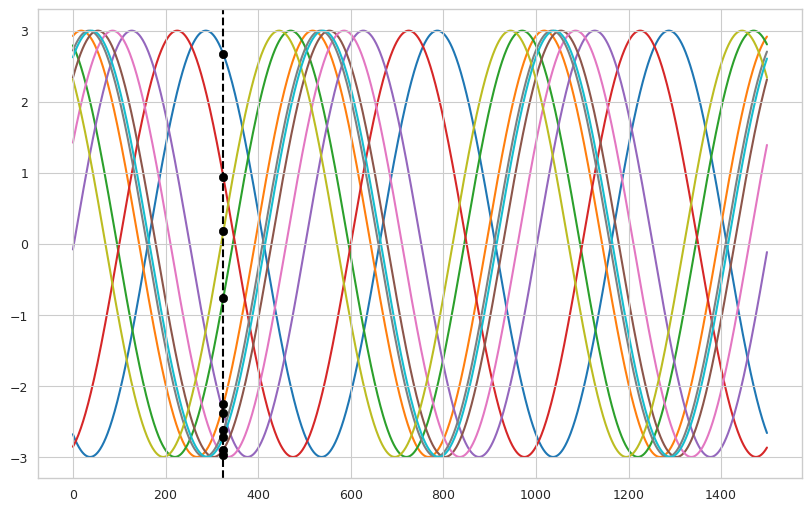

In [7]:
fig, ax = plt.subplots()
Xdf.plot(ax=ax, zorder=-10, colormap="tab10")
t_a = 325
plt.axvline(x = t_a, ls="--")
plt.scatter(x=[t_a]*k, y=X[t_a, :], zorder=1)
if (k > 5):
    ax.get_legend().remove()
ax.grid(visible=True, which='Both', axis='x')
plt.show();plt.close()

We have added a dashed line at $t_a = 325$ to help you visualize the random variable $X_{325}$, which is part of this stochastic process. The dots illustrate that we have generated a $k$-sized sample of $X_{t_a}$. The sample corresponds to a row of the pandas dataset (while the different time series corresponds to columns).  We could use this sample to estimate the mean, variance and other statistical properties of $X_{t_a}$. **The key point is that in this example we have access to different realizations of the stochastic process**, different time series of the process. 

::: {.callout-tip  icon=false}

### Exercise 001

Do this, find the mean of $X_{t_a = 325}$ and plot a density curve for $X_{t_a = 325}$. Then change the value of k to 1000 and repeat the computation of the mean and density curve. What do you observe? Does the mean depend on the value of $t$? What about the variance of the time series, does it depend on t?

:::

::: {.callout-warning icon=false}

#### About the Role of u in the Code for this Example and the Consequences for Notation. 

Note, in particular that we do not care or need to know the value $u_0$, all we really care about is the value of $A(u)$ and $B(u)$ and the probabilistic distribution of these values. And in the Python code above this clearly shows, because we needed no variable for the value of u. All we had to do was *roll the dice*. Can you spot the lines of code where we did this dice rolling?

As consequence, we will often remove $u$ from our notation and we will write e.g. $X_t$ instead of $X(u, t)$. We will only include $u$ explicitly when we want to consider *different values of $u$*, that is different time series of the same stochastic process. 

We usually work with a single time series. We then use $x_t$ to refer to the particular value of the random variable $X_t$ that we have in our time series. 

:::


::: {.callout-note icon=false}

#### Making Noise 

The above example certainly defines an stochastic process. If you *roll the dices* again, you will get a different time series. But the individual time series themselves are certainly *not noisy*. In fact, they are *individually* ruled by a deterministic equation: once $w$ is fixed, there is nothing random about them.

Next we are going to introduce a different type of stochastic process that is, in comparison, extremely noisy. 

:::

::: {.callout-note icon=false}

#### White Noise, Different Shades of 

The following definition provides a first answer to our pending question of what noise means in the context of time series.

+ An stochastic process $W_t = W(u,t)$  is **white noise** if for each fixed time $t_k$, the random variables
  $$W_{t_1}, W_{t_2}, W_{t_3}, \ldots$$
  are **uncorrelated and identically distributed with mean zero**. In particular, they all have the same variance $\sigma^2$.  

+ A white noise stochastic process is called **independent white noise** if those $W_{t_i}$ random variables are (not just uncorrelated but) independent.  

+ Finally, an independent white noise is **gaussian white noise** if the $W_{t_i}$ are iid (independent identically distributed) normal variables $N(0, \sigma)$.

Let us implement a gaussian white noise process in Python. Let us suppose that the $W_{t_i}$ are iid standard normals $Z = N(0, 0.25)$. In particular this means that each row of the dataset is a sample (of size $k$) of $Z$. So this time we use that to fill the dataset by rows.

:::

In [8]:

W = np.zeros((n, k))

for i in range(n):
    W[i, :] = np.random.default_rng(i).normal(loc = 0, scale = 0.25, size = k)

Wdf = pd.DataFrame(W, columns=["W" + str(i) for i in range(k)])
Wdf.head()    

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9
0,0.031,-0.033,0.160,0.026,-0.134,0.090,0.326,0.237,-0.176,-0.316
1,0.086,0.205,0.083,-0.326,0.226,0.112,-0.134,0.145,0.091,0.074
2,0.047,-0.131,-0.103,-0.610,0.450,0.286,-0.081,0.193,0.070,-0.138
3,0.510,-0.639,0.105,-0.142,-0.113,-0.054,-0.505,-0.058,-0.216,0.831
4,-0.163,-0.044,0.416,0.165,-0.410,-0.001,-0.156,0.037,-0.402,0.060


Let us plot the $k$ time series that we have obtained as realizations of this stochastic process. Now that looks noisy!

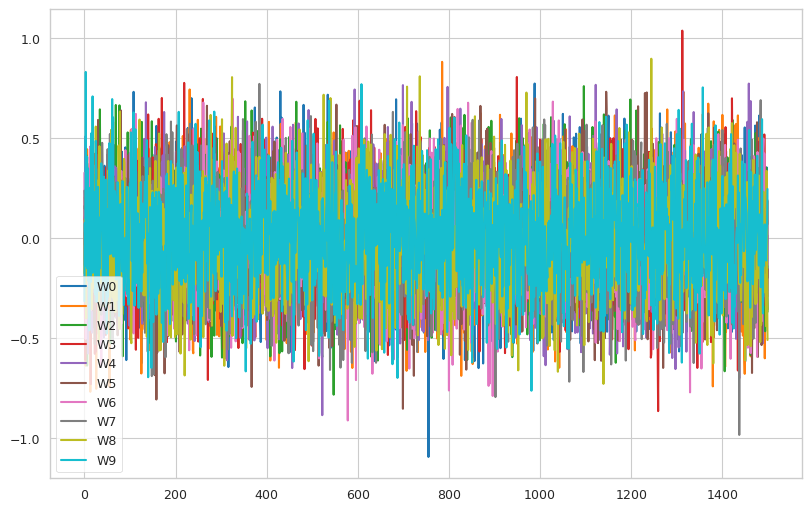

In [9]:
Wdf.plot(colormap="tab10")
plt.show();plt.close()

---

::: {.callout-note icon=false}

#### Combining the two examples

Let us now consider a combined stochastic process $Y$ which is simply the sum of the two preceding examples. That is, the random variable $Y_t$ is defined as
$$Y_t = X_t + W_t$$
for each value of $t$.

We can quickly visualize what that means in Python.

:::

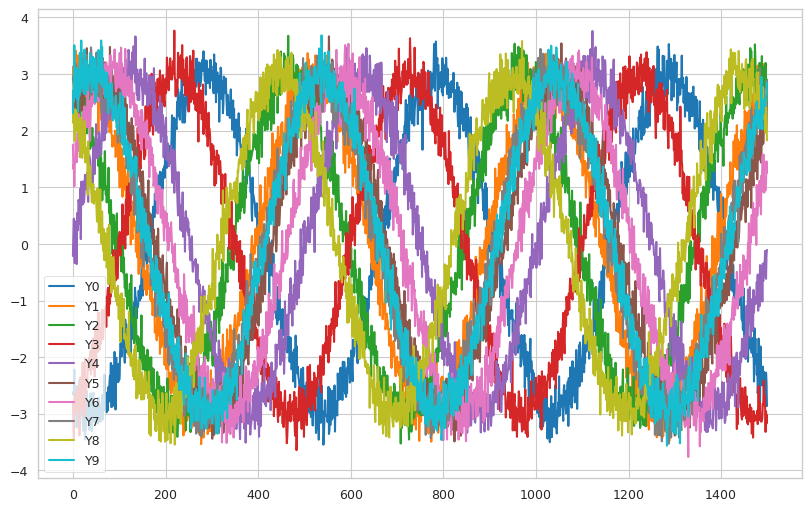

In [10]:
Y = X + W
Ydf = pd.DataFrame(Y, columns=["Y" + str(i) for i in range(k)])
Ydf.plot(colormap="tab10")
plt.show();plt.close()  

You can see that the time series in this last plot are beginning to look much more alike the ones we saw in the previous session. Each time series (= realization of the process = column of the dataset) displays a signal (the $X$ part) and a noise (the $W$ part). Most of our time series models in the next sessions will be similar: they include a signal part and a noise part that we *sum* to get the complete model structure (in additive models; we multiply them in multiplicative models). 

---

::: {.callout-note icon=false}

#### The Ensemble and a Mental Image of Stochastic Processes

After the predecing examples, a mental image of an stochastic process $Y(u, t)$ as some kind of two-way table or matrix is probably emerging:

$$
\left(
\begin{array}{cccccc}
Y(u_1, t = 1)&Y(u_2, t = 1)&Y(u_3, t = 1)&\cdots&Y(u_k, t = 1)&\cdots&\cdots\\
Y(u_1, t = 2)&Y(u_2, t = 2)&Y(u_3, t = 2)&\cdots&Y(u_k, t = 2)&\cdots&\cdots\\
\vdots&\vdots&\vdots&\vdots&\vdots&\vdots&\vdots\\
\vdots&\vdots&\vdots&\vdots&\vdots&\vdots&\vdots\\
Y(u_1, t = t_a)&Y(u_2, t = t_a)&Y(u_3, t = t_a)&\cdots&Y(u_k, t = t_a)&\cdots&\cdots\\
\vdots&\vdots&\vdots&\vdots&\vdots&\vdots&\vdots\\
\vdots&\vdots&\vdots&\vdots&\vdots&\ddots&\ddots
\end{array}   
\right)
$$
Once again: each column is a time series generated by the process using a fixed value of $u$ and each row is a sample of the ranndom variable $Y_{t_a}$ that corresponds to a fixed time instant $t_a$. Here we use the $Y(u, t)$ symbol to emphasize the different values of $u$.

However, be careful with a too literal interpretation. The dots try to suggest that there is a possible column for each point $u$ in the sample space $\Omega$, which can be continuous and high dimensional! So a better mental picture at leaast replaces the idea of rows with a horizontal *axis* (better yet, a copy of $\Omega$). For discrete time processes the idea that a row corresponds to an instant in tie is o, but keep in mind that there exist continuous time stochastic processes; and for those we need to replace the vertical dimension of this mental image with a continuous axis as well. And we need an additional axis for the values that the stochastic process generates (the $Y$ axis) This resulting set of points 
$$(t, u, Y(t, u))\in \mathbb R\times\Omega\times\mathbb R$$
is called the **ensemble** of the stochastic process and it contains all the possible time series that the stochatic process can possibly generate. [This web page](https://www.surajx.in/2019/07/bayesian-optimization---part-1-stochastic-processes/) contains some helpful visualizations of the ensemble for an stochastic process.

:::

::: {.callout-note icon=false}

#### How is this Relevant for Time Series Modeling?

As we have said, our models for time series assume a certain signal/noise structure of the time series that we are trying to first fit and then predict with the model. In particular, **we need to be able to recognize noise when we see it!** And that means that we need to be able to estimate the statistical properties of a time series to see if it qualifies as noise.

So, how do we do that? In statistics **the basis of any estimation is a sample**. And here is where things get tricky with time series. The random variables that form the stochastic process are obtained with a fixed time instant $t_a$. **A sample is a row-like section** of the stochastic process, as we have seen. But in Machine Learning our *sample* is **a time series, which is a  column-like section** of the process. To emphasize the problem, with a single time series (the usual situation) **we have a sample for $Y_{t_a}$ of sample size one!** How are we going to get estimates with this, the tiniest of samples?

:::


---

# Stationarity


::: {.callout-warning icon=false}

#### Recommended Video Watching

[9.1 Stationarity and differencing from [@hyndman2021fpp3]](https://www.youtube.com/watch?v=xIzEcEFi9_k)

:::

::: {.callout-note icon=false}

#### Strict Stationarity

The notion of stationarity offers a way out of this sampling problem. Remember that when we introduced white noise stochastic processes, one of its key properties was that the time series that form it are independent or at least uncorrelated. In particular if I show you a portion of a white noise series it is impossible to tell (to estimate) to which time values it corresponds. White noise series are time-shift invariant. 

This idea of time-shift invariance is at the core of the idea of stationarity. More precisely a stochastic process $Y_t$ is **strictly stationary** if the joint distribution of a random vector such as

$$\left(Y_{t_{a_1}}, Y_{t_{a_2}},\ldots, Y_{t_{a_s}}\right)$$

does not depend on the particular time instants $t_{a_1},\ldots,t_{a_s}$ for any vector length $s$. For example, a gaussian white noise process is, by definition, a strictly stationary stochastic process. 

Why is strict stationarity helpful? Because if the process is stationary then the entire time series can be used as a sample to estimate the (common) statistical properties. For example, to estimate the mean we can simply use as estimator the average of all the available time series values:

$$\hat\mu = \bar Y_t = \dfrac{Y_1+ Y_2 + \cdots + Y_n}{n}$$

Because the random variables $Y_1,\ldots,Y_n$ all have the same mean $\mu$. 

:::

---

:::{.callout-note icon=false}

####  Autocovariance and Autocorrelation (ACF)

A proper statistical estimate, like $\bar\mu$ above, is not complete until we understand its variability and sampling distribution. In order to do that, we turn into the variance of $\mu$:
$$
\operatorname{var}(Y_t) =  \operatorname{var}\left(\dfrac{Y_1+ Y_2 + \cdots + Y_n}{n}\right) = 
\dfrac{1}{n^2}\operatorname{cov}\left(\sum_{t = 1}^n Y_t, \sum_{s = 1}^n Y_s\right)
$$

Here we will use a very useful property of covariance: it is bilinear. Thus, if we have a linear combination of (finite variance) random variables 
$$U = \sum_{j = 1}^m a_j X_j,\qquad V = \sum_{k = 1}^r b_k Y_kj$$
then 
$$\operatorname{cov}(U, V) = \sum_{j = 1}^m\sum_{k = 1}^r a_jb_k  \operatorname{cov}(X_j, Y_k)
\qquad\qquad\qquad\qquad (1.13)$$
And besides
$$\operatorname{var}(U) = \operatorname{cov}(U, U)$$

With this:
$$
\operatorname{var}(Y_k) = \dfrac{1}{k^2}\sum_{t = 1}^k\sum_{s = 1}^k\operatorname{cov}\left( Y_t, Y_s\right)
$$
Let us give the covariances that appear here a name; the **autocovariance function** of the stochastic process is 
$$
\gamma_Y(s, t) = \operatorname{cov}\left( Y_t, Y_s\right)
$$
As usual the problem with variance is that it depeds on the scale of the variable. So we define an absolute version. The **autocorrelation function (ACF)** is:
$$
\rho_Y(s, t) = \dfrac{\operatorname{cov}(Y_t, Y_s)}{\sqrt{\operatorname{cov}(Y_t, Y_t)\operatorname{cov}(Y_s, Y_s)}}
$$
and it is always a number between -1 and 1.

:::

::: {.callout-note icon=false}

####  Autocovariance and Autocorrelation (ACF) for Strictly Stationary Processes

<!-- If we apply this to a gaussian white noise time series $W_t$ we will find that because of its properties: 
$$
\operatorname{cov}\left(W_t, W_s\right) = 
\begin{cases}
\sigma_w^2& s = t\\[3mm]
0 & s \neq t
\end{cases},
$$
where $\sigma_w^2$ is the variance of the white noise time series.  -->

Now suppose that the stochastic process is strictly stationary. Then for any time shift $k$ we have that the distribution of the vectors $(Y_t, Y_s)$ and $(Y_{t + k}, Y_{s + k})$ must be the same. In particular 
$$
\operatorname{cov}\left( Y_t, Y_s\right) = \operatorname{cov}(Y_{t + k}, Y_{s + k})
$$
and this means (take $k = -t$) that **the autocovariance and ACF only depends on the difference $h = s - t$**. For a stationary time series we simplify thenotation by defining:
$$
\gamma_Y(h) = \gamma_Y(0, h) = \gamma_Y(t, t + h), \qquad \rho_Y(h) = \rho_Y(0, h) = \rho_Y(t, t + h)
$$
Note that the value of $t$ is irrelevant in these equations.

:::

---

::: {.callout-note icon=false}

#### Again: why is this relevant or useful? Time Lags of a Time Series.

Remember that the problem is that we only have one time series (in fact $n$ values of the time series):
$$y_1, y_2, \ldots, y_n$$
But if we can assume stationarity, then we can use **lagged (time-shifted) copies of our time series**. Given an integer $h$  we define the corresponding lagged copy of the time series as:
$$
z_1 = y_{1 + h}, \ldots, z_n = y_{n+h}
$$
And then **all the lagged values** $z_1, \ldots, z_n$ can be used as values for $Y_{t + h}$ when estimating
$$
\rho_Y(h) = \rho_Y(t, 0) = \rho_Y(t, t + h)\qquad\text{In particular we always have:}\quad \rho_Y(0) = 1
$$
We emphasize that this is possible because the stationarity guarantees that the result only depends on $h$. In the non stationary case a lag of the time series would be useless here. 

By the way, now we can answer the other pending question: **the presence of autocorrelation in time series is what makes time series special and different from other regression problems we have seen.**. For example. we need to take it into account when doing estimates like the one for $\operatorname{var}(Y_t)$ above. In standard linear regression models we assume that we have samples formed by *iid (in particular independent and therefore uncorrelated)* copies of the random variables in the problem.

:::

::: {.callout-note icon=false}

#### Lagged Time Series in Python

Let us see how this works in practice using Python. We will use the same Canadian gas example that we used in the previous session, so we will begin my loading and preparing it. Then we will use the [`shift` method in pandas](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.shift.html) to obtain the first 15 lagged time series out of it.

:::

In [11]:
can_gas = pd.read_csv('../4_1_Introduction_to_Forecasting/tsdata/fpp3/Canadian_gas.csv')
can_gas["Month"] = pd.to_datetime(can_gas["Month"], format="%Y %b")
can_gas.set_index('Month', drop=True, inplace=True)
can_gas.head()

,Volume
Month,
1960-01-01,1.431
1960-02-01,1.306
1960-03-01,1.402
1960-04-01,1.170
1960-05-01,1.116


Let us also create the nixtlaverse version of this.

In [12]:
fpppy_path = '/wd/data/fpppy/'
can_gas_nx = pd.read_csv(fpppy_path + '/canadian_gas.csv', parse_dates=['ds'])
can_gas_nx.head()

,unique_id,ds,y
0,Canadian gas production,1960-01-01,1.431
1,Canadian gas production,1960-02-01,1.306
2,Canadian gas production,1960-03-01,1.402
3,Canadian gas production,1960-04-01,1.170
4,Canadian gas production,1960-05-01,1.116


Now we create the lags, for $h= 0$ (a copy of the original time series) to $h = 15$. We use a dictionary for this. Note that the range in the for loop uses 16 to get 15 lags, and the way we add names to the columns. We will examine the result and analyze the consequences below.

In [13]:
can_gas_lags = pd.DataFrame({"lag" + str(lag): can_gas["Volume"].shift(lag) for lag in range(16)})
can_gas_lags

,lag0,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
Month,,,,,,,,,,,,,,,,
1960-01-01,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-02-01,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-03-01,1.402,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-04-01,1.170,1.402,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-05-01,1.116,1.170,1.402,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004-10-01,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792,16.905,17.588,17.384
2004-11-01,17.832,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792,16.905,17.588
2004-12-01,19.453,17.832,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792,16.905


And the nixtlaverse version would be:

In [14]:
can_gas_nx_lags = can_gas_nx.join(pd.DataFrame({"lag" + str(lag): can_gas_nx["y"].shift(lag) for lag in range(1, 16)})) 
can_gas_nx_lags 

,unique_id,ds,y,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
0,Canadian gas production,1960-01-01,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Canadian gas production,1960-02-01,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Canadian gas production,1960-03-01,1.402,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Canadian gas production,1960-04-01,1.170,1.402,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canadian gas production,1960-05-01,1.116,1.170,1.402,1.306,1.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,Canadian gas production,2004-10-01,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792,16.905,17.588,17.384
538,Canadian gas production,2004-11-01,17.832,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792,16.905,17.588
539,Canadian gas production,2004-12-01,19.453,17.832,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792,16.905
540,Canadian gas production,2005-01-01,19.528,19.453,17.832,17.827,16.907,17.641,17.878,17.166,18.093,17.848,18.333,17.782,19.244,19.144,17.720,17.792


::: {.callout-note icon=false}

#### Overlaping Lags and ACF Estimation. 

Our plan is to use the columns of this table of lags to *estimate the ACF*. For example, to estimate $\rho_Y(1)$ we will compute the correlation between the first two colums of this dataframe. Obviously, the lagged time series contain missing values, because we can not get **out of sample** lagged values. Thus the lag1 time series has one missing value, the lag2 series has two missing values, and so on. In partiular this means that our estimate of $\rho_Y(1)$ will be based in $n - 1$ values, the estimate of $\rho_Y(2)$ is based on $n-1$, etc. This implies that the sampling support for the values of $\rho_Y(h)$ decreases as we consider bigger lags. In practice we will therefore attribute more importance to the estimates of the first values of the ACF (for smaller lags) and we will rely less on estimates based on bigger lags. 

:::

::: {.callout-note icon=false}

#### ACF Values and Plot in Python: statsmodels and nixtla

We could try a manual computation of the ACF values, but getting it right means dealing with those missing values in the right way. Instead, we can use the solution provided by the `statsmodels` library. 

:::

In [15]:
can_gas_ACF = sm.tsa.stattools.acf(can_gas["Volume"])
can_gas_ACF

array([1.        , 0.98630929, 0.97389895, 0.95920413, 0.94504748,
       0.93438939, 0.92468341, 0.9240095 , 0.92392526, 0.92766874,
       0.93077195, 0.93117848, 0.93330983, 0.91975445, 0.90729176,
       0.8922351 , 0.87805474, 0.866886  , 0.85682908, 0.85573537,
       0.85563592, 0.85900748, 0.86164275, 0.86181158, 0.86357829,
       0.85043021, 0.83791706, 0.82291474])

The library also includes a function for a nice graphical representation of the ACF values, a so called **ACF plot**, that appears in the left panel below. In the right panel we show the plot of the original time series and the 4-lag time series: 

/tmp/ipykernel_95/2468042639.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


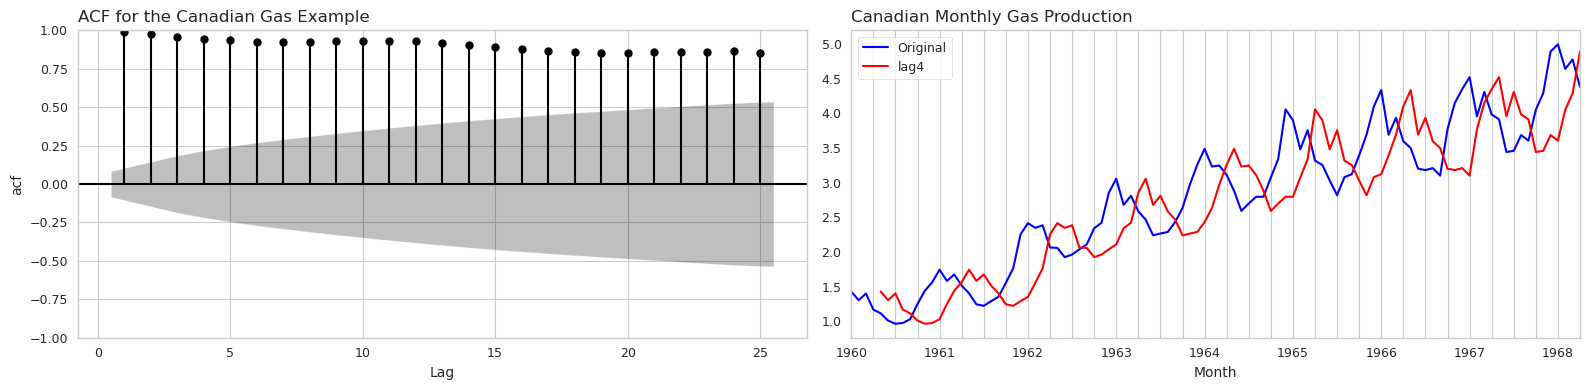

In [16]:
which_lag = 4
fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)
ax0 = axs[0]
sm.graphics.tsa.plot_acf(can_gas["Volume"], ax=ax0, lags=25, zero=False, title='ACF for the Canadian Gas Example')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = can_gas["Volume"].head(100).plot(color="blue", label="Original")
ax1 = can_gas_lags[f"lag{which_lag}"].head(100).plot(color="red", label=f"lag{which_lag}")
ax1.set_title('Canadian Monthly Gas Production')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
ax1.legend()
plt.tight_layout()
plt.show();plt.close()


::: {.callout-note icon=false}

#### Initial Interpretation of the Canadian Gas ACF Plot

Recall that the definition of the ACF values is 
$$\rho_Y(h) = \rho_Y(t, t + h)$$
and that $\rho$ represents correlation. That means that $\rho$ measures how strong is the linear relation between $Y_t$  and $Y_{t + h}$. The right panel illustrates that in this example this relation is very strong: for most of the time series span, the slope of the graph for $Y_t$ and $Y_{t + h}$ are very similar. This holds clearly for small values of $h$ but if you factor in the seasonility, the relation carries on for not so small values of $h$. This is what the ACF on the left illustrates: the height of each vertical bar indicates a value of $\rho_Y(h)$ for increasing lags. And we can see in this example correlation values close to 1 even after 25 lags. Not ealso that there is an uptick in the correlations at lag=12, corresponding to the seasonality period of the time series. 

Note also the shaded area in the ACF plot. Soon we will see that we can use statistics to test the hypothesis that the ACF values are significantly different from 0. An ACF out of the shaded area is significantly different from 0. 

Finally note that you can select the number of lags to include in the ACF plot, and that we have selected `zero=False` to exclude the ACF at lag = 0, which is *always* equal to 1 and sometimes messes with the vertical scale of the plot. 

:::

::: {.callout-tip  icon=false}

### Exercise 02

Replace `lag4` with `lag12` above and repeat the plots. 

:::

::: {.callout-note icon=false}

#### Lag Plots

The lag plots are scatterplots of $Y_t$ vs $Y_{t + h}$ for different values of $h$. They are  particularly interesting for smaller values of $h$ and for small multiples of the seasonal frequency. They offer a different visualization of the information of the ACF. Below we include the lag plots for all the lags included in an extended version of `can_gas_lag`. Note that the correlations are very strong, and in the case of lags = 12 and 24 they are even stronger than those of their close neighbors. 

:::

/tmp/ipykernel_95/1828456769.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


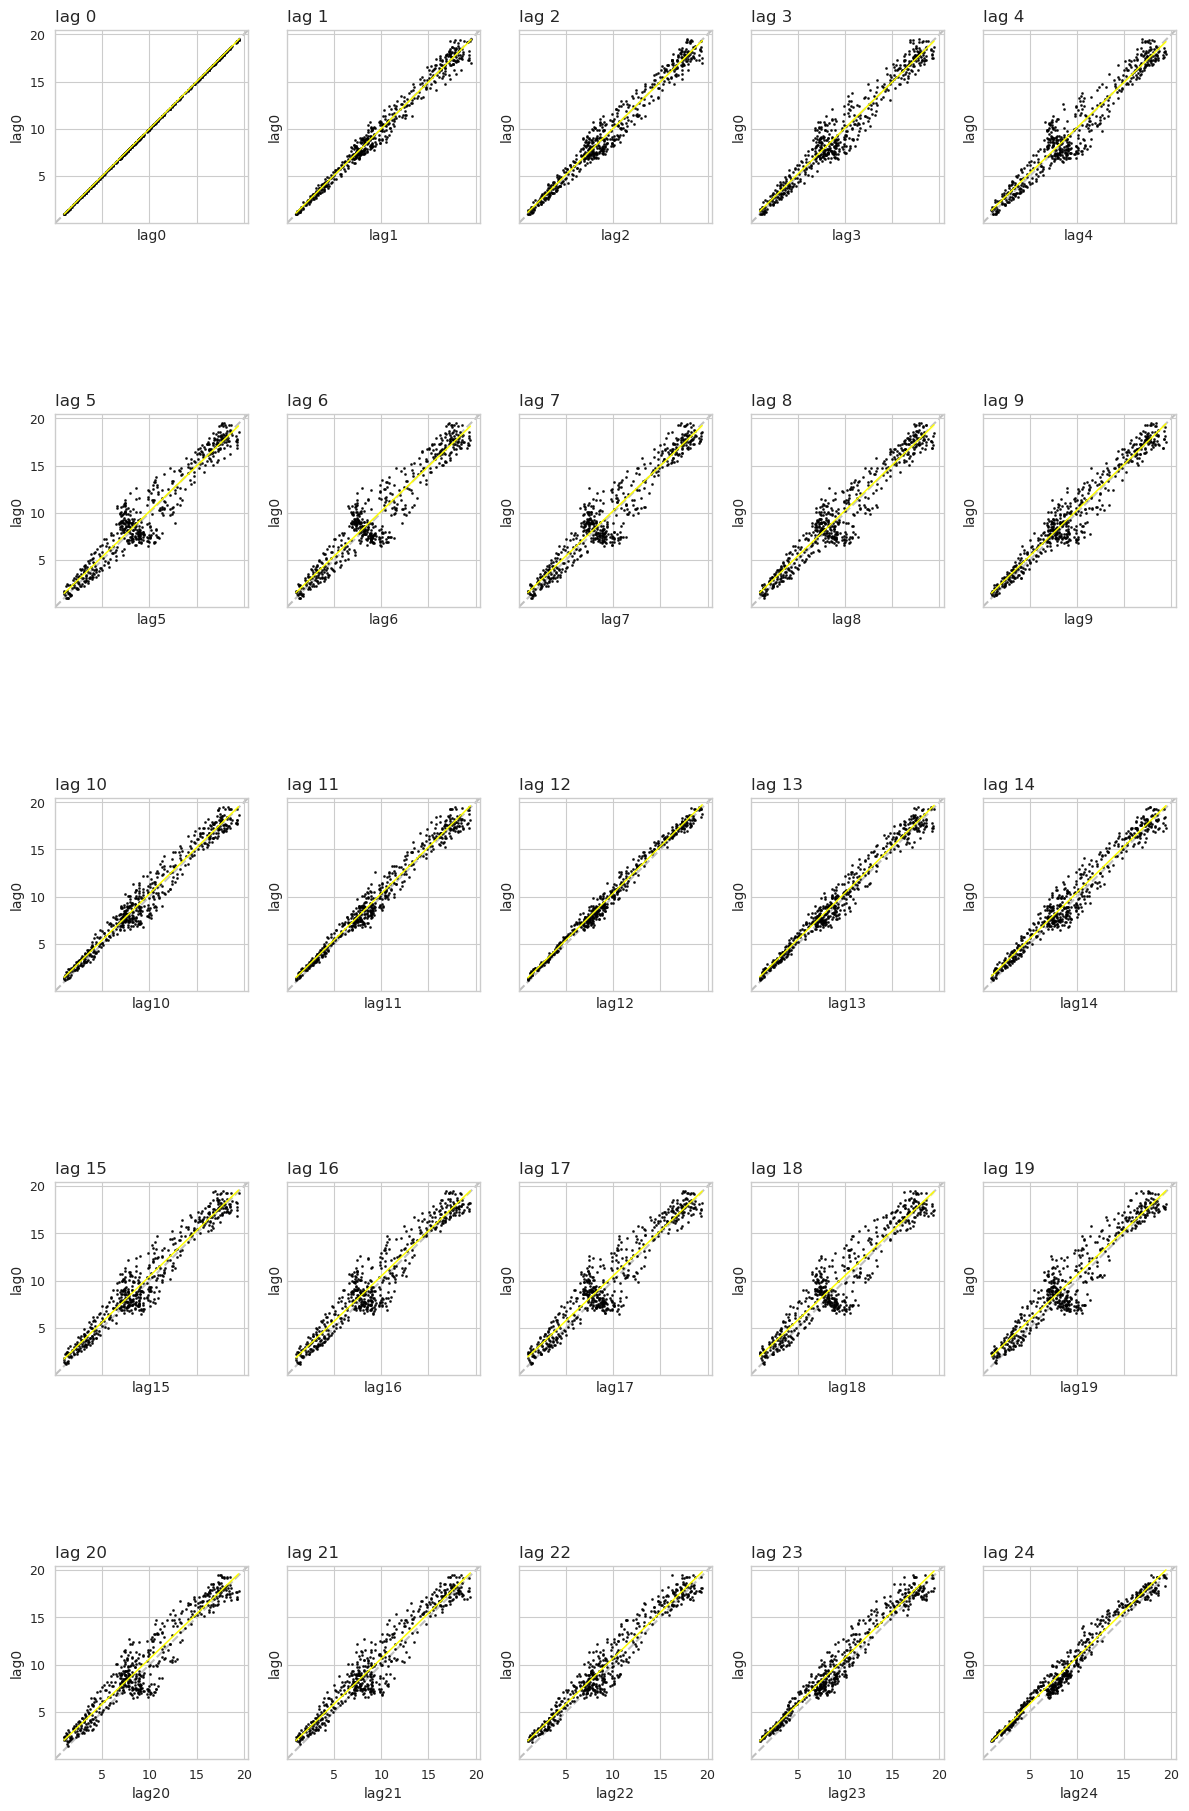

In [17]:
can_gas_lags = pd.DataFrame({"lag" + str(lag): can_gas["Volume"].shift(lag) for lag in range(25)})
fig, axs = plt.subplots(5, 5, figsize=(12,20), sharex=True, sharey=True)
for (i, ax) in enumerate(axs.ravel()):
    sns.regplot(x = can_gas_lags.iloc[:, i], y = can_gas_lags.iloc[:, 0], order=1, ax = ax, 
    line_kws=dict(linewidth=1, color="yellow"), scatter_kws=dict(s=1)) 
    lim = ax.get_xlim()
    ax.plot(lim, lim, 'k--', alpha=.25, zorder=-10)
    ax.set(xlim=lim, ylim=lim, title=f'lag {i}', aspect='equal')
plt.tight_layout()
plt.show();plt.close()

---

::: {.callout-note icon=false}

#### ACF for (Gaussian) White Noise

The mean of a white noise process $W_t$ is $\mu_W = 0$. The autocovariance function is:
$$
\gamma_W(s, t) = 
\begin{cases}
\sigma_W^2& s = t\\[3mm]
0 & s \neq t
\end{cases}
$$
and so the ACF equals 1 for $t = 0$ and is $0$ for any value $t > 0$. Let us plot the ACF for one of the gaussian white noise series in the columns of the dataset `Wdf` in an example above (any column will do). As you can see, all tha ACF values are very small , almos all of them inside the shaded region (this is a 95% significance test, so we expect some ACF values to appear significant at random; but even in those cases the values are anyway very small). This behavior is of course to be expected, because the random variables $W_t$ and $W_{t+h}$ in a gaussian white noise time series are not only uncorrelated, but also independent. A consequence of their definition is that **all gaussian white noise time series are strictly stationary.**
:::

/tmp/ipykernel_95/2990417472.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


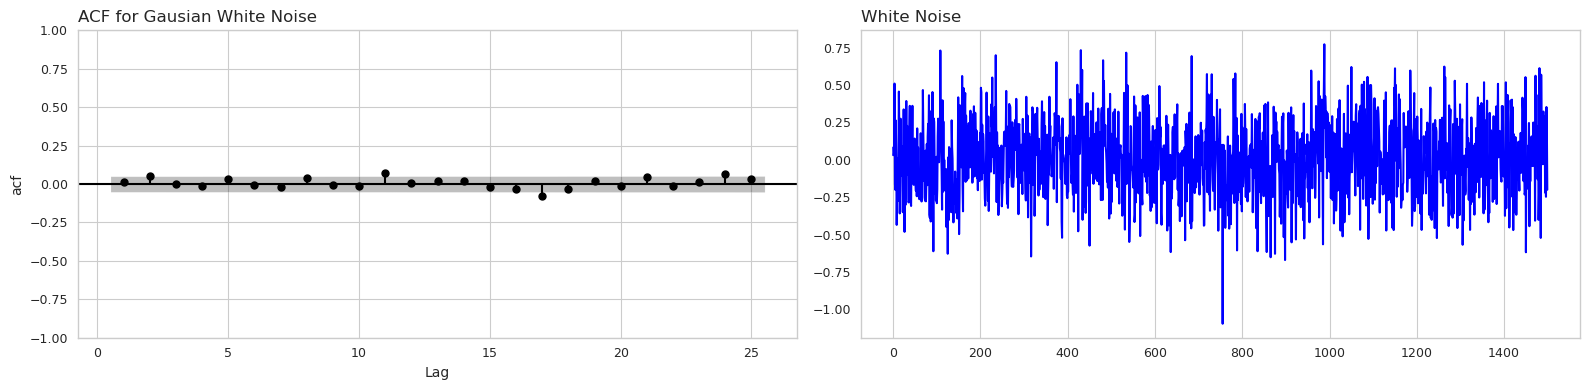

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(Wdf["W0"], ax=ax0, lags=25, zero=False, title='ACF for Gausian White Noise')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = Wdf["W0"].plot(color="blue", label="Original")
ax1.set_title('White Noise')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()

::: {.callout-note icon=false}

#### Weak Stationarity. 

As we have seen, strict stationarity opens the possibility of using the time series values to make estimates of the statistical properties of the underlying stochastic process, even though we only have a realization of that process. However, the problem is that checking if an observed time series is strictly stationary is not easy at all. We can however relax the equirements and still get the properties we need to serve as the basis for modeling. 

An stochastic process (and its realizations as time series) is called **weakly stationary** if:
1. Its mean and variance are constant (do not depend on $t$)
2. The autocovariance function $\gamma(t, s)$ only depends on the difference $|s - t|$.

Every strictly stationary process is clearly also weakly stationary.The advantage of this notion of weak stationarity is that it is simpler to check if it does not hold, as we will see below. Because of this, from now on, the word **stationary** will be used to mean **weakly stationary.** And if we mean strict stationarity we will make it explicit.   

:::

---

# Detecting Non Stationarity

::: {.callout-note icon=false}

#### Trend, Stable Variance and Stationarity. 

If a time series has a trend, that means that the average value (the mean) of $Y_t$ and $Y_{t + h}$ will not be the same for certain values of $h$. In particular this means that **a series with a trend can not posibly be stationary.** The presence of a trend can be detected in the ACF because the values do not approach zero or approach zero very slowly (with a linear decay). We have already seen an example in the ACF for the Canadian gas time series. 

If the variance of a time series increases or decreases clearly asin dofferent sections of the time series,  then just as in the case of a non constant mean,  this shows that the variance of $Y_t$ is not constant and so **a time series with non constant variance can not posibly be stationary.** The following example of the recordings inf a sismograph during an earthquake (Example 1.7 from [@shumwaystoffer2017]) is a clear case of non constant variance in the time series, as the amplitude of the oscilations recorded as sismometer measures increase during the earthquake. The ACF of this series exhibits an oscilating (but non periodic) slow decay.


:::

/tmp/ipykernel_95/3315002690.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


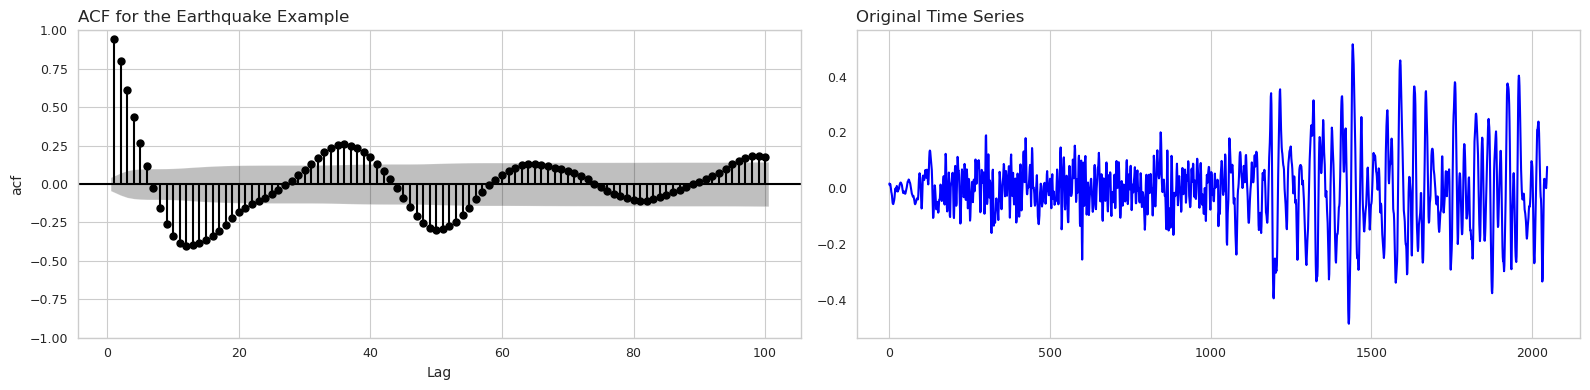

In [19]:
EQ5 = pd.read_csv('./EQ5.csv')
fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)
ax0 = axs[0]
sm.graphics.tsa.plot_acf(EQ5["seismograph"], ax=ax0, lags=100, zero=False, title='ACF for the Earthquake Example')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = EQ5["seismograph"].plot(color="blue", label="Original")
ax1.set_title('Original Time Series')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()

---

::: {.callout-note icon=false}

#### Random Walks.


This is another important example of a time series that appears in may applications. Here we will use it  to see yet another example of ACF.

A stochastic process $Y_t$ is a **random walk** if it satisfies the equation 
$$Y_t = Y_{t -1} + W_t, \qquad\text{where }W_t\qquad\text{ is white noise.}$$
If we  assume that $Y_1 = 0$ note that 
$$Y_3 = Y_2 + W_3 = W_2 + W_3\qquad\text{ and, in general }Y_k = \sum_{i=2}^k W_k$$
Thus a random walk is a sum of white noise values. This in turn means that the autocovariance of a random walk is:
$$
\gamma_Y(s, t) = \min(s, t)\,\sigma_w^2
$$
where $\sigma_w^2$ is the variance of the white noise time series. This shows that the autocovariance depends on the particular values of $t$ and $s$ and therefore **a random walk is not stationary**.

:::

::: {.callout-note icon=false}

#### Random Walks in Python.

Let us simulate a random walk in Python. The only thing we need to do is to create a white noise time series (we will use the `W1` column from the `Wdf` example above) and then use the recursive equation above to generate the rest of the values $y_2, y_3, \ldots$ as a cumulative sum of the white noises series values. 

:::

In [20]:
rng = np.random.default_rng(2024)
RW = Wdf["W1"].cumsum()
RWdf = pd.DataFrame({'RW':RW})

And now lets plot the time series and its ACF. Note again this pattern of slow decay in the ACF values:

/tmp/ipykernel_95/1939923379.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


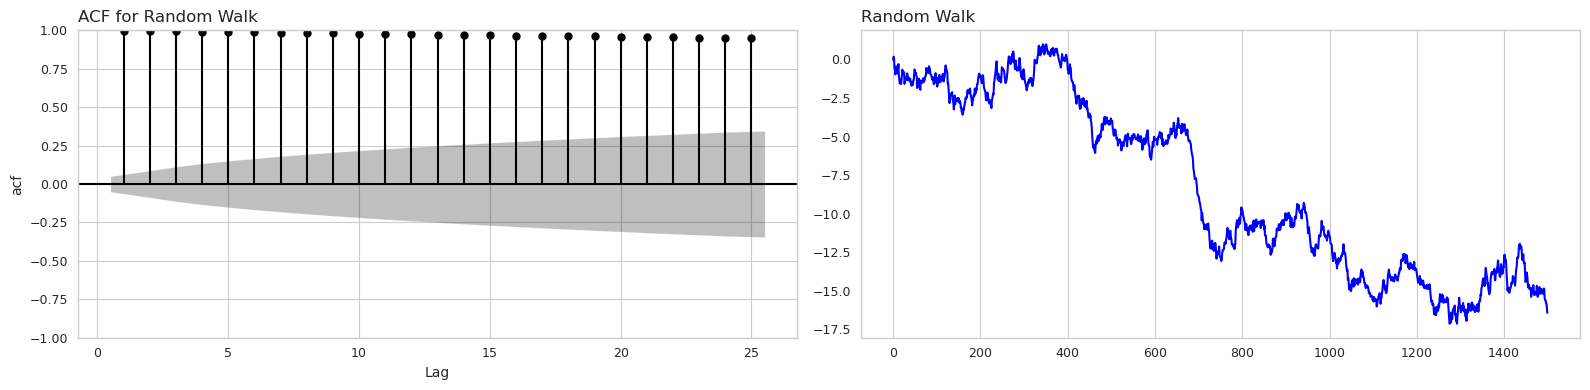

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(RWdf["RW"], ax=ax0, lags=25, zero=False, title='ACF for Random Walk')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = RWdf["RW"].plot(color="blue")
ax1.set_title('Random Walk')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()


---

::: {.callout-note icon=false}

#### Seasonality and Stationarity

Is a seasonal time series stationary? As we will see this is not a simple question. We saw before an example, the sinusoidal stochastic process
$$X_t = 3 \sin(2\pi t/500 + A)$$
where $A$ is uniformly distibuted in $[0, 2\pi]$.  And in the exercise following that example we tried to gain some intuition that the mean and variance of the time series do not depend on $t$. For this time series stationarity can be established formally (see e.g. this online reference from the [EE2S31 Signal Processing course at TU Delft, page 28](https://sps.ewi.tudelft.nl/Education/courses/ee2s31/slides/SP5.pdf)). However, the ACF exhibits a pattern that we would normally associate with non stationarity.

:::

/tmp/ipykernel_95/4208411932.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


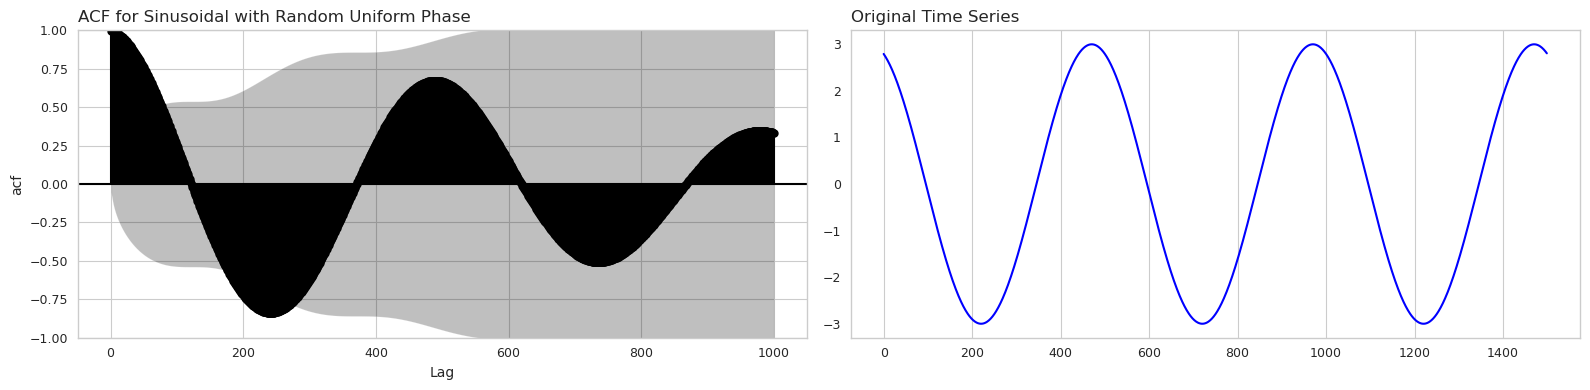

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(Xdf["X2"], ax=ax0, lags= 1000, zero=False, title='ACF for Sinusoidal with Random Uniform Phase')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = Xdf["X2"].plot(color="blue")
ax1.set_title('Original Time Series')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()


Let us consider a second example of a sinusoidal stochastic process $Z-t$ given by 
$$Z_t = 3 \sin(2\pi t/100 + B)$$
but this time let us assume that the phase $B$ is a random normal variable with mean 0 and standard deviation 0.5. We repeat the same steps, fist plotting a large number of realizations of this process (many time series that only differ on the *roll of the dice*).

In [23]:
n = 1500
k = 1000

Z = np.zeros((n, k))
rng = np.random.default_rng(2024)

Ts = np.arange(n)

for i in range(k):
    A = rng.normal(loc= 0, scale=0.5, size=1)
    Z[:, i] = 3 * np.sin(Ts/50 + A)

Zdf = pd.DataFrame(Z, columns=["Z" + str(i) for i in range(k)])
Zdf.head()


,Z0,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,...,Z990,Z991,Z992,Z993,Z994,Z995,Z996,Z997,Z998,Z999
0,1.476,2.195,1.627,-1.403,-1.924,0.101,1.252,0.756,2.360,1.100,...,-2.424,1.482,0.224,0.769,-1.446,-1.551,-0.755,0.762,-0.305,-0.602
1,1.528,2.236,1.677,-1.350,-1.878,0.161,1.307,0.813,2.396,1.156,...,-2.388,1.534,0.284,0.826,-1.393,-1.499,-0.696,0.820,-0.245,-0.543
2,1.579,2.275,1.727,-1.296,-1.831,0.221,1.360,0.871,2.432,1.211,...,-2.351,1.585,0.343,0.884,-1.340,-1.447,-0.638,0.878,-0.186,-0.484
3,1.630,2.314,1.776,-1.241,-1.783,0.280,1.414,0.928,2.466,1.265,...,-2.313,1.636,0.403,0.941,-1.286,-1.394,-0.579,0.935,-0.126,-0.425
4,1.680,2.352,1.824,-1.186,-1.734,0.340,1.466,0.985,2.500,1.320,...,-2.275,1.686,0.462,0.998,-1.232,-1.340,-0.520,0.992,-0.066,-0.366


And let us again plot the different realizations of $Z_t$ as time series:

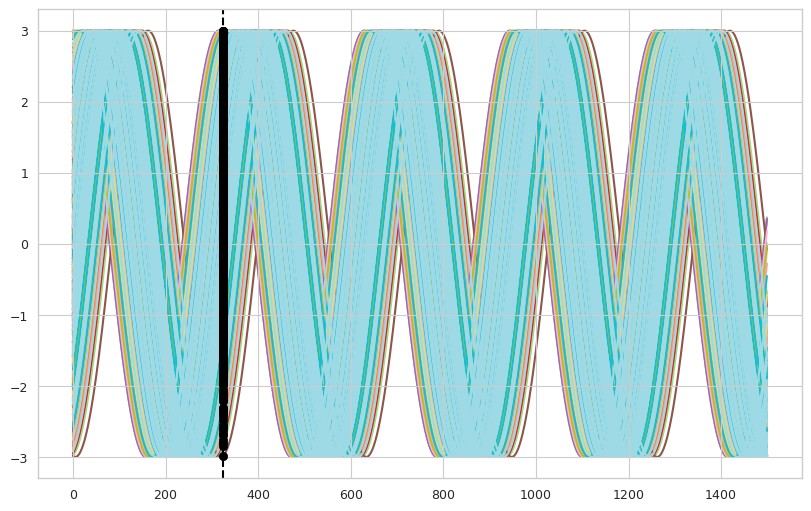

In [24]:
fig, ax = plt.subplots()
Zdf.plot(ax=ax, zorder=-10, colormap="tab20")
t_a = 325
plt.axvline(x = t_a, ls="--")
plt.scatter(x=[t_a]*k, y=Z[t_a, :], zorder = 1)
if (k > 10):
    ax.get_legend().remove()
plt.show();plt.close()

::: {.callout-tip  icon=false}

### Exercise 003

In this case, does the mean of the time series depend on the value of $t$? And what about the variance?

:::

In this case it can also be shown formally that the process is not stationary. Now let us look at the corresponding ACF:

/tmp/ipykernel_95/3862686891.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


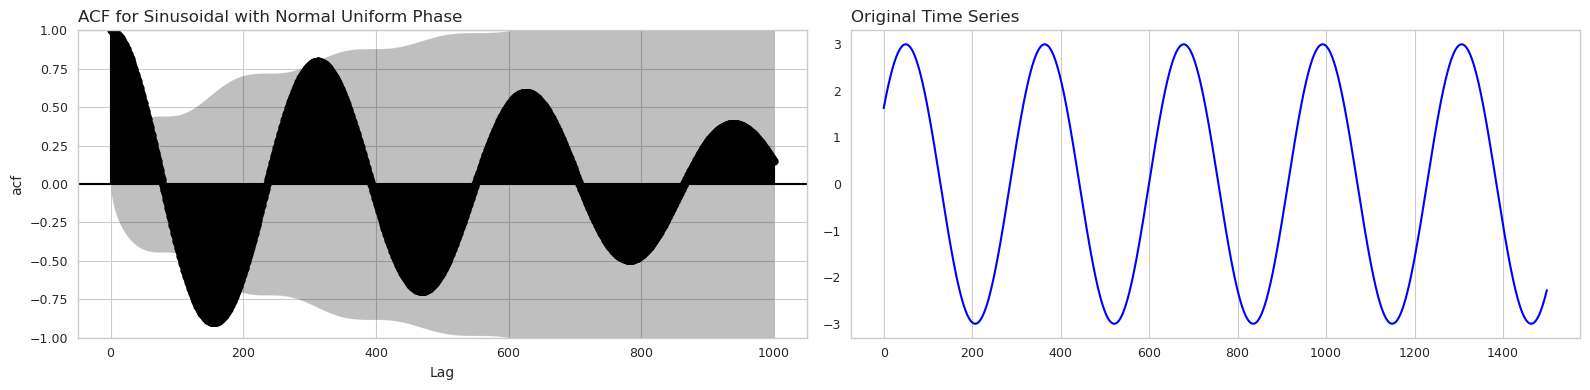

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(Zdf["Z2"], ax=ax0, lags=1000, zero=False, title='ACF for Sinusoidal with Normal Uniform Phase')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = Zdf["Z2"].plot(color="blue")
ax1.set_title('Original Time Series')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()


::: {.callout-warning icon=false}

#### Detecting Stationarity in Time Series Samples

As you can see, it looks pretty similar! The take home message from this examples is that **the ACF is helpful in making us *suspect* non stationarity, but it is no formal proof.** In fact, it is important to understand that the exact same time series can be a result of both sinusoidal examples: once we have rolled either the uniform or the normal dice, there is no way to tell which one was used to obtain the phase. As we will see in the next session, we will use models that assume that the time series originates from a stationary process. But ultimately, this is an assumption. We will use the results in this session as EDA and preprocessing to remove the non-stationary behavior so that the time series we feed into our models will look *compatible* with a generating stationary process. Whether this modeling strategy is right or not is left for the performance evaluation step and will be discussed further in the next session.

:::

---

::: {.callout-note icon=false}

#### Hypothesis Tests for Stationarity

A number of hypothesis tests have been devised to test for stationarity. However, as with the ACf plots, they must be used with caution as they can even result in apparently contradictory conlusions. A couple of commonly such tests are: 

+ **ADF Test: uses as null hypothesis: the time series is not stationary and non seasonal.** 
+ **KPSS Test: Uses as null hypothesis: the time series is stationary and non seasonal.** 

Both tests are implemented in `statsmodels.tsa`, we will apply both of them to some of our examples.

::: 

::: {.callout-warning icon=false}

#### Recommended Video Watching

[Unit Root Tests from [@hyndman2021fpp3]](https://otexts.com/fpp3/stationarity.html#unit-root-tests)

:::

For the random walk (which we know for certain to be non stationary!) the resulting p-values confirm the non stationarity of the series.

In [26]:
RW_adf = adfuller(RWdf["RW"])
RW_kpss = kpss(RWdf["RW"])
RW_adf[1], RW_kpss[1]

/tmp/ipykernel_95/596027656.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  RW_kpss = kpss(RWdf["RW"])


(np.float64(0.7918327048062517), np.float64(0.01))

For the stationary sinusoidal (uniform random phase) the p-value of the ADF tells us to reject the null. This means that the series is either stationary or seasonal, the later being true. But the KPSS test fails to reject the null, even though we know it to be false because of (strong) seasonality.

In [27]:
X_2_adf = adfuller(Xdf["X2"])
X_2_kpss = kpss(Xdf["X2"], nlags="legacy")
X_2_adf[1], X_2_kpss[1]

/tmp/ipykernel_95/2546339701.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  X_2_kpss = kpss(Xdf["X2"], nlags="legacy")


(0.0, np.float64(0.1))

In the case of the  non stationary sinusoid (normal random phase) the ADF again rejects the null, but the KPSS does not reject it, even though the series is not stationary and it is seasonal.

In [28]:
Z_adf = adfuller(Zdf["Z2"] )
Z_kpss = kpss(Zdf["Z2"], nlags="legacy")
Z_adf[1], Z_kpss[1]

/tmp/ipykernel_95/2005724078.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  Z_kpss = kpss(Zdf["Z2"], nlags="legacy")


(0.0, np.float64(0.1))

::: {.callout-tip  icon=false}

### Exercise 004

What happens with the earthquake data?

:::

---

# Transformations to Achieve Stationarity

### Dealing with trend and seasonality

::: {.callout-note icon=false}

#### Introduction

A series with a trend or a series with seasonality can not be stationary. In the case of a trend, the mean of the time series is not constant. In the case of seasonality, the mean of the time series is constant but the variance is not. However, some important forecasting model families are based on the assumption that the time series is stationary. This is the case for ARIMA models, for example. Therefore, often the first step in the analysis of a time series is  to remove the trend and seasonality. In order to do that we introduce the important concept of **differencing**.

:::

::: {.callout-note icon=false}

#### Differencing

The **backshift or lag operator** $B$ is defined by:
$$BY_t = Y_{t - 1}$$
The powers of this backshift operator can be used to express further lags of the time series. For example:
$$B^3Y_t = Y_{t - 3}$$
The operation 
$$
(1 -B)Y_t 
$$
is a **(first order regular ) difference of the time series.** Similarly, for a seasonal time series with period $p$ we define the **first order seasonal difference** operator to be:
$$
(1 -B^p)Y_t =  Y_t - Y_{t - p}
$$
Note of course that when we apply this operations to a time series, the first values of the difference will be missing because they require past values that are not present in our data.

In Python we can use `diff` to obtain these differences of a time series. For example, for the Canadian cas example (recall, seasonality 12) the first order regular and seasonal difference are obtained with:

:::

In [29]:
can_gas["Volume_d1"] = can_gas["Volume"].diff()
can_gas["Volume_d12"] = can_gas["Volume"].diff(periods=12)
can_gas.head(18)

,Volume,Volume_d1,Volume_d12
Month,,,
1960-01-01,1.431,NaN,NaN
1960-02-01,1.306,-0.125,NaN
1960-03-01,1.402,0.096,NaN
1960-04-01,1.170,-0.232,NaN
1960-05-01,1.116,-0.054,NaN
1960-06-01,1.011,-0.105,NaN
1960-07-01,0.966,-0.045,NaN
1960-08-01,0.977,0.011,NaN
1960-09-01,1.031,0.054,NaN


Let us plot the original time series and also the differenced ones. 

/tmp/ipykernel_95/2050797953.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


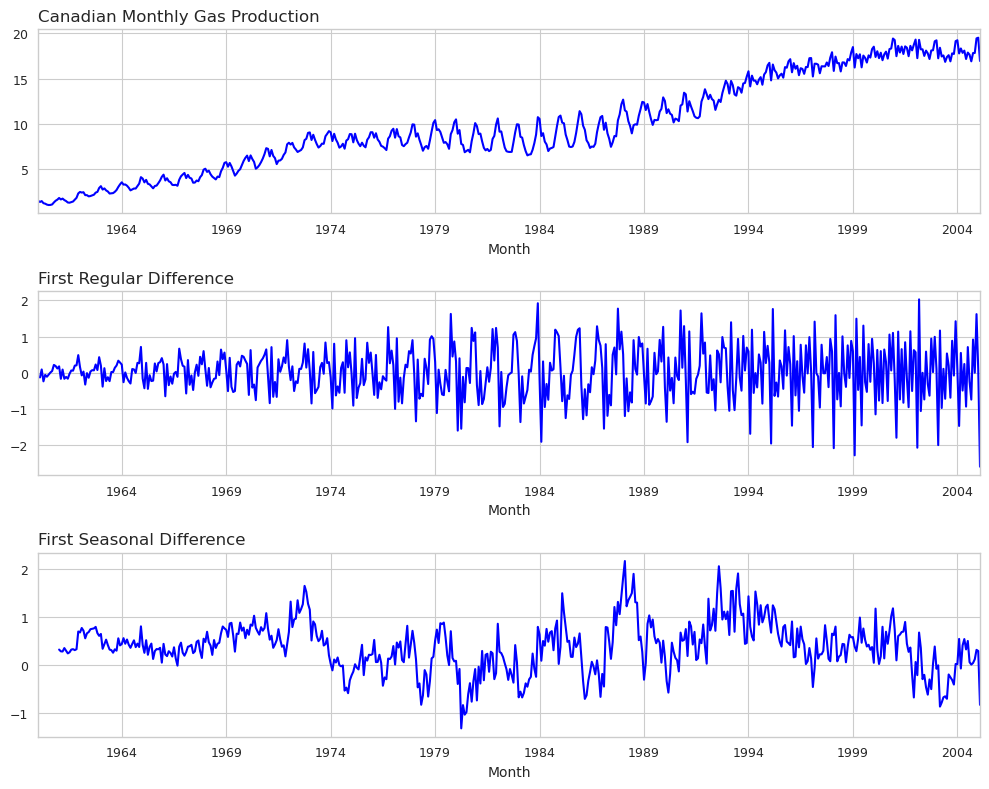

In [30]:
fig, axs = plt.subplots(3, 1, figsize=(10,8), sharex=False, sharey=False)

ax0 = axs[0]
can_gas["Volume"].plot(color="blue", ax=ax0)
ax0.set_title('Canadian Monthly Gas Production')

ax1 = axs[1]
can_gas["Volume_d1"].plot(color="blue", ax=ax1)
ax1.set_title('First Regular Difference')

ax2 = axs[2]
can_gas["Volume_d12"].plot(color="blue", ax=ax2)
ax2.set_title('First Seasonal Difference')

plt.tight_layout()
plt.show();plt.close()


::: {.callout-tip  icon=false}

### Exercise 005

Do the same with the other time series examples in this session, but only take seasonal differences in seasonal time series!

:::

::: {.callout-note  icon=false}

### Differencing to remove trends and seasonality

After some experimenting, you should have noticed that:
+ Regular differencing removes (or at least greatly reduce) the trend in a time series. If the series is seasonal, it does not remove seasonality.
+ Seasonal differencing removes (or at least greatly reduce) seasonality in a seasonal time series. And if the series has a trend seasonal differencing may also reduce or even cemove the trend.

Therefore, when we hve a time series that exhibits seasonality and or a trend we will proceed as follows:
+ If the series has seasonality we will apply seasonal differencig tom remove it. If it also has a trend, we examine whether seasonal differencing has removed the trend. If it has not, then we apply regular differencing to remove the trend.
+ If the series has a trend but no seasonality then we only apply regular differencing to remove it. 

Keep also in mind that sometimes a single difference (seasonal or regular) may not be enough to do the job. In some cases we need to apply a second difference of a certain kind to remove a seasonal behavior or a trend. But we will never apply a third difference of the same kind, as this leads to too complex modeling dynamics.

:::

::: {.callout-note  icon=false}

### Australian Beer Example

The data in aus_production.csv` contains Quarterly production of selected commodities in Australia from 1956 to 2010. This data is [contained in the R library `tsibbledata`](https://cran.r-project.org/web/packages/tsibbledata/tsibbledata.pdf), and is also used in the book [@hyndman2021fpp3]. Let us begin by reading the data.

:::

In [31]:
ausprod  = pd.read_csv('../../../../4_1_Introduction_to_Forecasting/aus_production.csv')
ausprod

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956 Q1,284,5225.0,189.0,465,3923,5
1,1956 Q2,213,5178.0,204.0,532,4436,6
2,1956 Q3,227,5297.0,208.0,561,4806,7
3,1956 Q4,308,5681.0,197.0,570,4418,6
4,1957 Q1,262,5577.0,187.0,529,4339,5
...,...,...,...,...,...,...,...
213,2009 Q2,398,NaN,NaN,2160,57471,238
214,2009 Q3,419,NaN,NaN,2325,58394,252
215,2009 Q4,488,NaN,NaN,2273,57336,210
216,2010 Q1,414,NaN,NaN,1904,58309,205


To parse the quarter data correctly we need to do a string replacement:

In [32]:
ausprod["Quarter"] =  ausprod["Quarter"].str.replace(' ', '-')
ausprod.head()


,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956-Q1,284,5225.0,189.0,465,3923,5
1,1956-Q2,213,5178.0,204.0,532,4436,6
2,1956-Q3,227,5297.0,208.0,561,4806,7
3,1956-Q4,308,5681.0,197.0,570,4418,6
4,1957-Q1,262,5577.0,187.0,529,4339,5


In [33]:
ausprod["Date"] = pd.to_datetime(ausprod["Quarter"])
ausprod.head()

/tmp/ipykernel_95/1995653433.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ausprod["Date"] = pd.to_datetime(ausprod["Quarter"])


,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date
0,1956-Q1,284,5225.0,189.0,465,3923,5,1956-01-01
1,1956-Q2,213,5178.0,204.0,532,4436,6,1956-04-01
2,1956-Q3,227,5297.0,208.0,561,4806,7,1956-07-01
3,1956-Q4,308,5681.0,197.0,570,4418,6,1956-10-01
4,1957-Q1,262,5577.0,187.0,529,4339,5,1957-01-01


In [34]:
ausprod.set_index('Date', drop=True, inplace=True)
ausprod.head()

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
Date,,,,,,,
1956-01-01,1956-Q1,284,5225.0,189.0,465,3923,5
1956-04-01,1956-Q2,213,5178.0,204.0,532,4436,6
1956-07-01,1956-Q3,227,5297.0,208.0,561,4806,7
1956-10-01,1956-Q4,308,5681.0,197.0,570,4418,6
1957-01-01,1957-Q1,262,5577.0,187.0,529,4339,5


We will focus in the time series corresponding to beer production.  We can visualize the time series and its ACF. Both plots tell you about clear trend and seasonality with period 4.

/tmp/ipykernel_95/4088216739.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


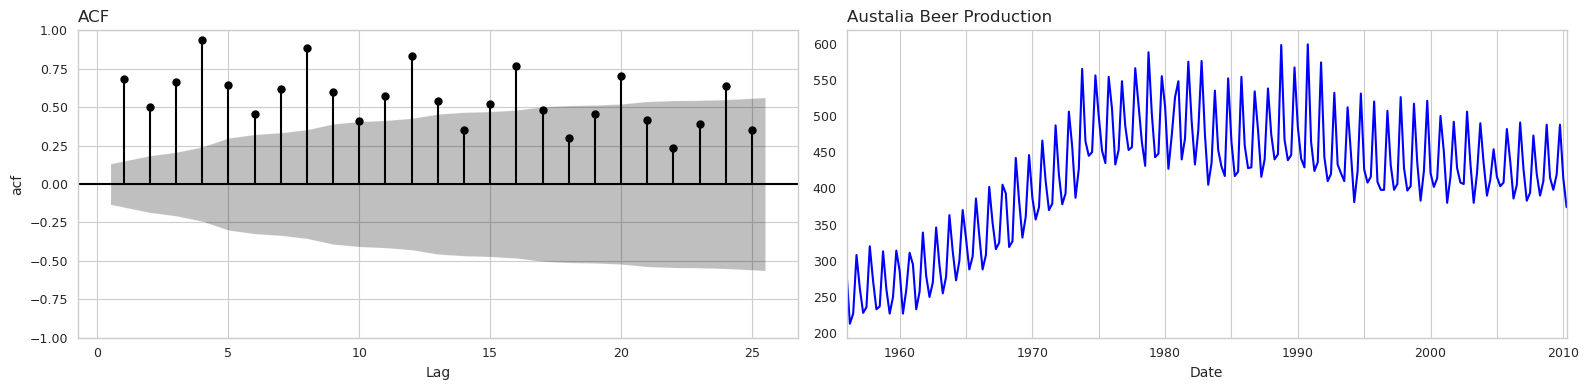

In [35]:
df_ts = ausprod
var = "Beer"

fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(df_ts[var], ax=ax0, lags=25, zero=False, title='ACF')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = df_ts[var].plot(color="blue")
ax1.set_title('Austalia Beer Production')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()


As described, we first take a seasonal difference:

In [36]:
ausprod["Beer_sd4"] = ausprod["Beer"].diff(periods=4)
ausprod.head(12)

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Beer_sd4
Date,,,,,,,,
1956-01-01,1956-Q1,284,5225.0,189.0,465,3923,5,NaN
1956-04-01,1956-Q2,213,5178.0,204.0,532,4436,6,NaN
1956-07-01,1956-Q3,227,5297.0,208.0,561,4806,7,NaN
1956-10-01,1956-Q4,308,5681.0,197.0,570,4418,6,NaN
1957-01-01,1957-Q1,262,5577.0,187.0,529,4339,5,-22.0
1957-04-01,1957-Q2,228,5651.0,214.0,604,4811,7,15.0
1957-07-01,1957-Q3,236,5317.0,227.0,603,5259,7,9.0
1957-10-01,1957-Q4,320,6152.0,222.0,582,4735,6,12.0
1958-01-01,1958-Q1,272,5758.0,199.0,554,4608,5,10.0


Let us visualize the result. Note that we remove the missing data before plotting the ACF:

/tmp/ipykernel_95/213964748.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


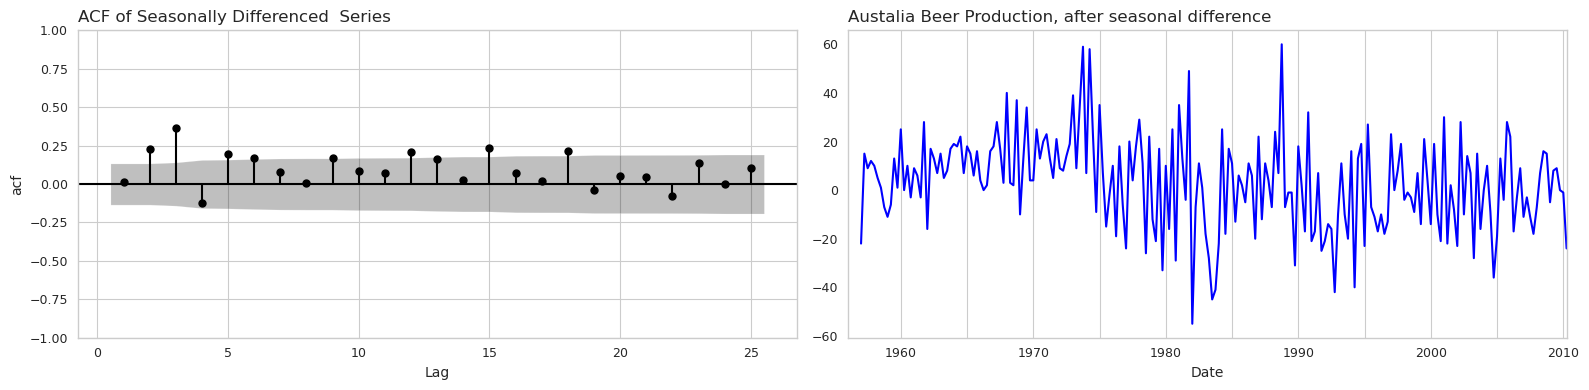

In [37]:
df_ts = ausprod
var = "Beer_sd4"

fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(df_ts[var].dropna(), ax=ax0, lags=25, zero=False, title='ACF of Seasonally Differenced  Series')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = df_ts[var].plot(color="blue")
ax1.set_title('Austalia Beer Production, after seasonal difference')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()

The plots, the ACF in particular, shows that we have managed to remove seasonality. But since there is still some hint of a trend, we will now apply a regular difference (to the already seasonally differenced data) and plot the result again. 

/tmp/ipykernel_95/1882162051.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


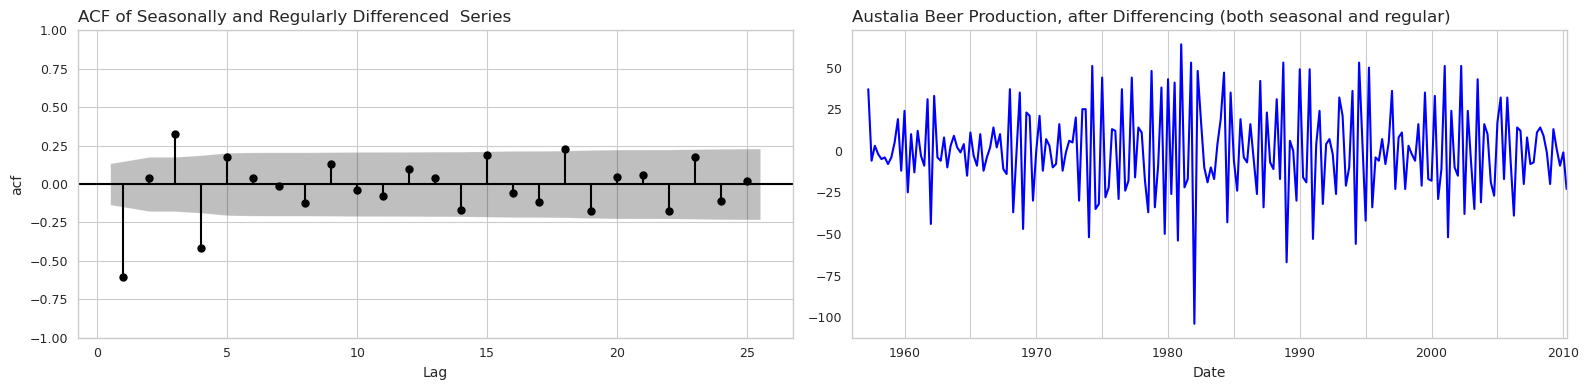

In [38]:
ausprod["Beer_sd4_d1"] = ausprod["Beer_sd4"].diff()

df_ts = ausprod
var = "Beer_sd4_d1"

fig, axs = plt.subplots(1, 2, figsize=(16,4), sharex=False, sharey=False)

ax0 = axs[0]
sm.graphics.tsa.plot_acf(df_ts[var].dropna(), ax=ax0, lags=25, zero=False, title='ACF of Seasonally and Regularly Differenced  Series')
ax0.set(ylim=(-1,1), xlabel='Lag', ylabel='acf')

ax1 = axs[1]
ax1 = df_ts[var].plot(color="blue")
ax1.set_title('Austalia Beer Production, after Differencing (both seasonal and regular)')
ax1.grid(visible=True, which='both', axis='x')
ax1.grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()

As we will see in the next session, this resulting ACF with only a few significant initial terms is a good starting point for modeling with SARIMA models. Let us check the stationarity 

In [39]:
ausbeer_diff = ausprod["Beer_sd4_d1"].dropna()
ausbeer_adf = adfuller(ausbeer_diff)
ausbeer_kpss = kpss(ausbeer_diff)
ausbeer_adf[1], ausbeer_kpss[1]

/tmp/ipykernel_95/882291498.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  ausbeer_kpss = kpss(ausbeer_diff)


(np.float64(9.951622692226875e-11), np.float64(0.1))

ADF rejects the null of non-stationarity (and non seasonality) and KPSS does not reject the null of stationarity (and non seasonality). Therefore they agree and give us another confirmation that the differenced time series appears like the the result of a stationary process. 

::: {.callout-note  icon=false}

### Automatic differencing order determination

The `pmdarima` contains a couple of functions `ndiff` and `nsdiffs` that indicate the recommended number of seasonal and regular differences to apply to get to this stationary behavior. If you apply them to the beer production time series you see that the recommendation agrees with what we have done.  

**Always take this recommendation with skepticism!** The best way to proceed is to experiment with different orders of differencing and check the results with the ACF plot. Train your eyes and your good judgement and trust them more than you trust these automated procedures!

:::

In [40]:
pmd_ndiffs, pmd_nsdiffs = pmd.arima.ndiffs, pmd.arima.nsdiffs

print(f"Recommended number of regular differences: {pmd_ndiffs(ausprod['Beer'])}")
print(f"Recommended number of seasonal differences: {pmd_nsdiffs(ausprod['Beer'], 4)}") 

Recommended number of regular differences: 1
Recommended number of seasonal differences: 1


/opt/conda/envs/mlmiin/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/envs/mlmiin/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/envs/mlmiin/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/envs/mlmiin/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/envs/mlmiin/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will b

In [41]:
nsdiffs(ausprod['Beer'].values, period=4)

1

::: {.callout-important icon=false}

#### Choosing the right seasonality is critical

One of the first steps in time series EDA is the identification of the seasonality period of the time series, if seasonal behavior is present. This is critical because the seasonality will determine the period of the seasonal difference. If we choose the wrong period, the differencing will not remove the seasonality. Even worse, a spurious dynamic may be introduced in the time series that will severely aff ect the performance of the models you try to fit to the data. **Double check the seasonality period of the time series  before proceeding further with the analysis!**

The sampling frequency ot the time series is a good starting point to determine the possible seasonality periods. We already suggested checking the [table in Section 2.1 of [@h]](https://otexts.com/fpppy/nbs/02-graphics.html#the-seasonal-period) can be used as a guide for this relation between the tyoe of observations (yearly, monthly, weekly, daily, hourly) and the seasonal period that we can expect to find in our data.

:::

### Box-Cox transformations to stabilize the variance

::: {.callout-note icon=false}

#### Introduction to the Box-Cox family of transformations

A series whose variance changes over time is not stationary. In order to stabilize the variance we can use different transformations. One of the most popular is the Box-Cox transformation. This transformation is defined as:
$$
Y_t^{(\lambda)} =
\begin{cases}
\dfrac{Y_t^\lambda - 1}{\lambda} & \text{if }\lambda \neq 0\\[3mm]
\log(Y_t) & \text{if }\lambda = 0
\end{cases}
$$
Note in particular that:
+ For $\lambda = 0$ the transformation is the logarithm.
+ For $\lambda = 1$ the transformation is essentially the identity (with a unit shift).
+ For $\lambda = 0.5$ the transformation is the square root.
+ For $\lambda = 2$ the transformation is the square.

Therefore the Box-Cox family of transformations includes the logarithm and power transformations. The goal of this transformation is to make the variance of the time series homogeneous through the time span of the series.

The parameter $\lambda$ that best achieves this is estimated by maximizing the log-likelihood of the transformed data, and we will use the `sktime` implementation of the Box-Cox transformation to do this.


:::

Let us see a famous example of a time series whose varinace increases with time: the airline passengers data. We will first plot the time series. The time plot clearly shows an increasing variance.

In [42]:
y = load_airline()
y.head()

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64

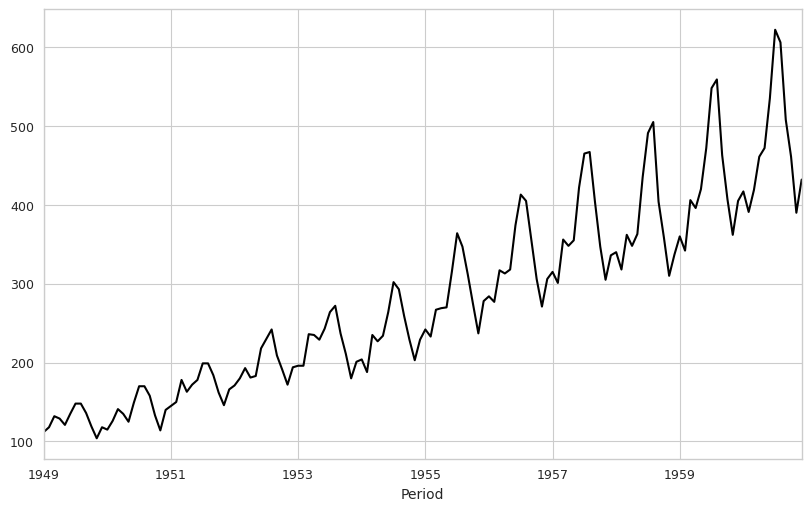

In [43]:
y.plot()
plt.show();plt.close()  


Next we apply the [`BoxCoxTransformer`](https://www.sktime.org/en/latest/api_reference/transformers/BoxCoxTransformer.html) from `sktime` to the time series. This transformation is implemented as a transformer, with the scikit interface that should be familiar to you by now. 

We apply the transformation to the time series and plot the result. We have upscaled the transformed time series by a factor of 20 to make the plot more useful. Note how the variance becomes more stable after the transformation.

We can get the best value of $\lambda$ as follows. Recall that if this value is close to 1, then the transformation is essentially the identity and therefore the variance of the time series is already stable.

In [44]:
from coreforecast.scalers import boxcox, boxcox_lambda

can_gas_lmbda = boxcox_lambda(can_gas_nx['y'], method='guerrero', season_length=12)
can_gas_lmbda

0.08700139820575714

In [45]:
can_gas_nx['y_boxcox'] = boxcox(can_gas_nx['y'], lmbda=can_gas_lmbda)
can_gas_nx.head()

,unique_id,ds,y,y_boxcox
0,Canadian gas production,1960-01-01,1.431,0.364
1,Canadian gas production,1960-02-01,1.306,0.270
2,Canadian gas production,1960-03-01,1.402,0.343
3,Canadian gas production,1960-04-01,1.170,0.158
4,Canadian gas production,1960-05-01,1.116,0.110


/tmp/ipykernel_95/616883987.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


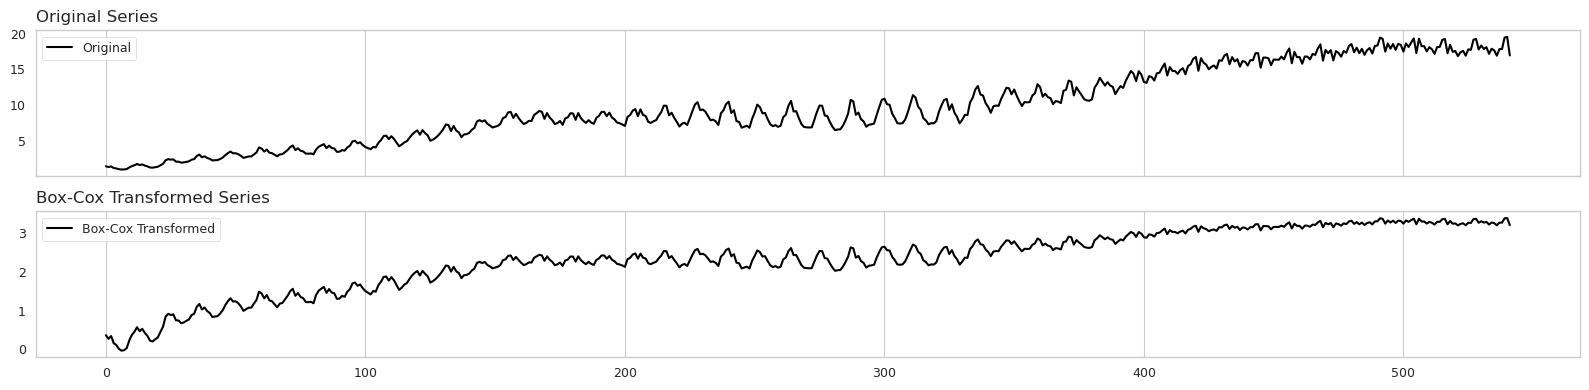

In [46]:
# Plot the original and Box-Cox transformed series, using subplots to show them side by side
fig, axs = plt.subplots(2, 1, figsize=(16,4), sharey=False, sharex=True)
can_gas_nx['y'].plot(label="Original", ax=axs[0])
can_gas_nx['y_boxcox'].plot(label="Box-Cox Transformed", ax=axs[1])
axs[0].legend()
axs[1].legend()
axs[0].set_title('Original Series')
axs[1].set_title('Box-Cox Transformed Series')
axs[0].grid(visible=True, which='both', axis='x')
axs[0].grid(visible=False, which='Major', axis='y')
axs[1].grid(visible=True, which='both', axis='x')
axs[1].grid(visible=False, which='Major', axis='y')
plt.tight_layout()
plt.show();plt.close()

::: {.callout-note icon=false}

#### How do we decide whether to apply a Box-Cox transformation?

The first thing that you should always do is plot the time series and check if the variance seems to change through time. If it does, then you should consider a Box-Cox transformation.
Once again: trust your eyes and your judgement more than any automated procedure!

However, in some cases we are not certain about whether we need to apply a Box-Cox transformation. In those cases, you can use some tests to check if the variance is stable. The most common test is the **Breusch-Pagan test**. This test is implemented in the `statsmodels` library and we will apply it below to the airline passengers time series. The null hypothesis of this test is that the variance is constant. Therefore if the p-value is small, then we reject the null hypothesis and conclude that the variance is not constant.

:::

To apply the test we need to fit a linear regression model to the time series and then apply the test to the residuals. We will use OLs from `statsmodels` to fit the model. First we create a pandas dataframe with the time series and an integer time index, using standard names to make the code reusable.

In [47]:
import statsmodels.formula.api as smf


Now we fit the linear regression

In [48]:
formula = 'y ~ ds'

olsr = smf.ols(formula, can_gas_nx).fit()


And we apply the Breusch-Pagan test to the residuals and extract the p-value:

In [49]:
import statsmodels.stats.api as sms
_, breusch_pagan_p_value, _, _ = sms.het_breuschpagan(olsr.resid, olsr.model.exog)
breusch_pagan_p_value # If the p-value is less than 0.05, then the residuals are heteroskedastic

np.float64(0.47980295530115447)

As expected for the airline passengers time series, the p-value is very small, indicating that the variance is not constant. A way to understand this is to plot the residuals of the linear regression model. We will do this below.

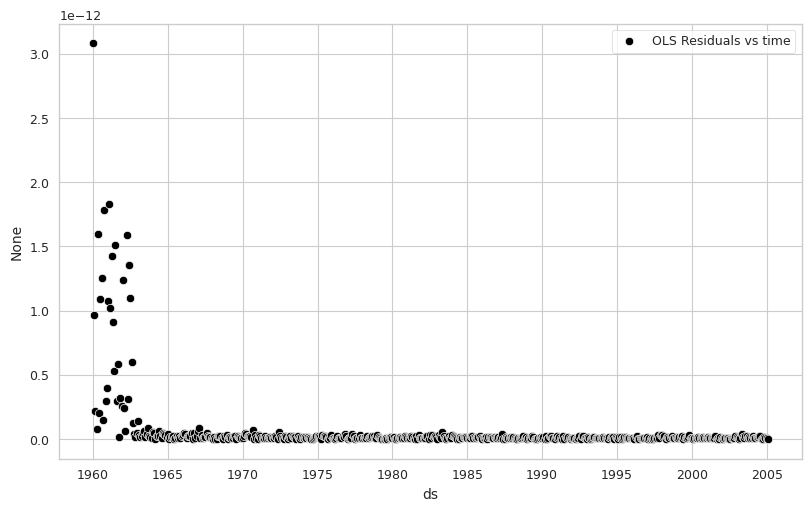

In [50]:
sns.scatterplot(x = can_gas_nx['ds'], y = np.abs(olsr.resid), label="OLS Residuals vs time")
plt.show();plt.close()

The *funnel-like* shape of the residuals plot is a clear indication that the variance is not constant. There are other tests that can be used to check for this, but the Breusch-Pagan test is the most common one. Check this [Medium post by V. Cerqueira](https://medium.com/data-science/how-to-detect-heteroskedasticity-in-time-series-3413a8aa8da9) for further details (Cerqueira is one of the authors of [@Cerqueira2024]). You can aso play with the online interactive tool in [Section 3.1 of *Forecasting: Principles and Practice*](https://otexts.com/fpp3/transformations.html#mathematical-transformations)

# Resampling a Time Series  

::: {.callout-note icon=false}

#### Resampling

Even though resampling is not directly connected with the notion of stationarity, it is a frequently used tool in the analysis of time series and you may come across it in your work. Resampling is the process of changing the sampling frequency of the time series. For example, you may have an hourly time series and you want to convert it to a daily time series. This is a resampling operation. We can of course only resample to a lower frequency: you can not resample daily data to hourly data!


Let us see a couple of examples to understand how this works. We will use the `resample` method in pandas to do this.

:::

#### Pedestrian Count Example

This is (quote): *A dataset containing the hourly pedestrian counts from 2015-01-01 to 2016-12-31 at 4 sensors in the city of Melbourne.*

Check this [link to the dataset](https://tsibble.tidyverts.org/reference/pedestrian.html) for more information about the dataset. We will load the data and select one of the sensors () to work with.



In [51]:
pedestrians = pd.read_csv('../4_1_Introduction_to_Forecasting/tsdata/tsibble/pedestrian.csv')
pedestrians = pedestrians[pedestrians["Sensor"] == "Bourke Street Mall (North)"]
pedestrians.drop(columns=["Sensor"], inplace=True)
pedestrians

,Date_Time,Date,Time,Count
14566,2015-02-16T13:00:00Z,2015-02-17,0,61
14567,2015-02-16T14:00:00Z,2015-02-17,1,16
14568,2015-02-16T15:00:00Z,2015-02-17,2,15
14569,2015-02-16T16:00:00Z,2015-02-17,3,17
14570,2015-02-16T17:00:00Z,2015-02-17,4,9
...,...,...,...,...
30975,2016-12-31T08:00:00Z,2016-12-31,19,2467
30976,2016-12-31T09:00:00Z,2016-12-31,20,1730
30977,2016-12-31T10:00:00Z,2016-12-31,21,1342
30978,2016-12-31T11:00:00Z,2016-12-31,22,1409


In [52]:
pedestrians["Date_Time"] = pd.to_datetime(pedestrians["Date_Time"])
pedestrians.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16414 entries, 14566 to 30979
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   Date_Time  16414 non-null  datetime64[ns, UTC]
 1   Date       16414 non-null  object             
 2   Time       16414 non-null  int64              
 3   Count      16414 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(2), object(1)
memory usage: 641.2+ KB


In [53]:
pedestrians.set_index('Date_Time', drop=True, inplace=True)
pedestrians.drop(columns=["Date", "Time"], inplace=True)
pedestrians

,Count
Date_Time,
2015-02-16 13:00:00+00:00,61
2015-02-16 14:00:00+00:00,16
2015-02-16 15:00:00+00:00,15
2015-02-16 16:00:00+00:00,17
2015-02-16 17:00:00+00:00,9
...,...
2016-12-31 08:00:00+00:00,2467
2016-12-31 09:00:00+00:00,1730
2016-12-31 10:00:00+00:00,1342


Now suppose that we want to convert this hourly time series to a daily time series. We can do this with the `resample` method in pandas. We will use the `sum` method to aggregate the hourly counts into daily counts, because we are interested in **the total number of pedestrians per day**. We would get it like this:

In [54]:
pedestrians_daily = pedestrians.resample('D').sum()
pedestrians_daily

,Count
Date_Time,
2015-02-16 00:00:00+00:00,3056
2015-02-17 00:00:00+00:00,23591
2015-02-18 00:00:00+00:00,25733
2015-02-19 00:00:00+00:00,30238
2015-02-20 00:00:00+00:00,33199
...,...
2016-12-27 00:00:00+00:00,39335
2016-12-28 00:00:00+00:00,38138
2016-12-29 00:00:00+00:00,28675


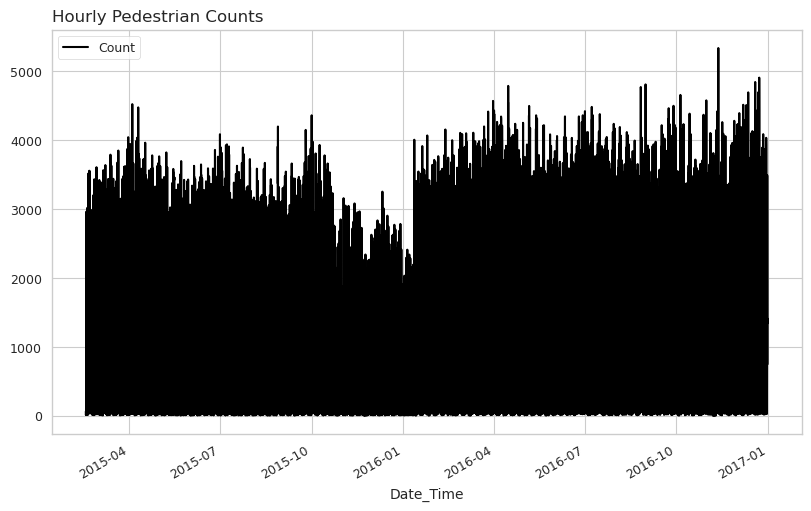

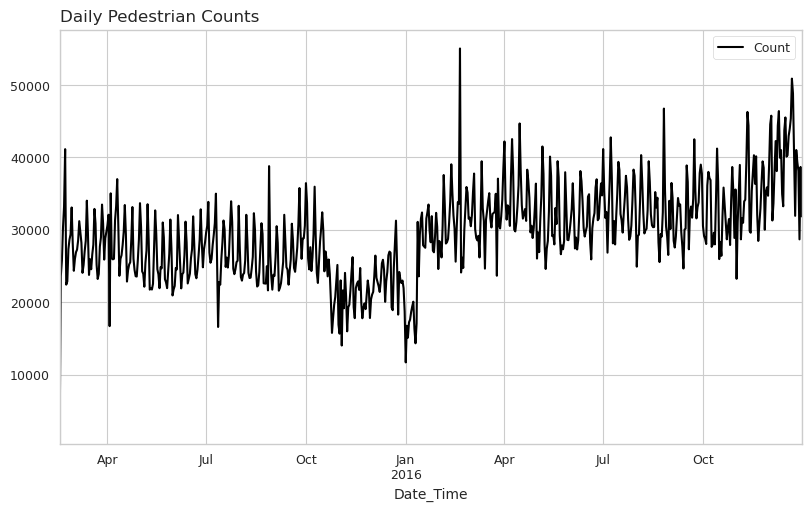

In [55]:
pedestrians.plot(label="Hourly")
plt.title("Hourly Pedestrian Counts")
pedestrians_daily.plot(label="Daily")
plt.title("Daily Pedestrian Counts")
plt.show();plt.close()

You can see in this example how the daily resampling operation allows us to more clearly identify seasonality patterns in the time series.

### Another resampling example: sea surface temperature data

In our previous session we already introduced the sea surface temperature data from the NOAA. We will use this data to show how to resample a time series to a different frequency. We will use the monthly data to create a yearly time series. The crucial difference with the preceding example is that we will use the `mean` method to aggregate the monthly temperatures into yearly temperatures. Adding up the temperatures would not make sense in this case, but finding the mean temperature for each year is a meaningful operation.

:::


In [56]:
NOAA_global_temp = pd.read_csv("../4_1_Introduction_to_Forecasting/noaa.globaltmp.comb.csv", parse_dates=True, index_col=0, na_values=-9999.)
NOAA_global_temp.columns = ['Temp_Anomaly'] 
NOAA_global_temp



,Temp_Anomaly
Date,
1850-01-01,-0.775
1850-02-01,-0.551
1850-03-01,-0.566
1850-04-01,-0.679
1850-05-01,-0.609
...,...
2024-08-01,0.972
2024-09-01,0.964
2024-10-01,1.063


Now let us apply the resampling operation:

In [57]:
NOAA_global_temp_yearly = NOAA_global_temp.resample('Y').mean()
NOAA_global_temp_yearly

/tmp/ipykernel_95/1696086621.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  NOAA_global_temp_yearly = NOAA_global_temp.resample('Y').mean()


,Temp_Anomaly
Date,
1850-12-31,-0.501
1851-12-31,-0.395
1852-12-31,-0.357
1853-12-31,-0.412
1854-12-31,-0.372
...,...
2020-12-31,0.705
2021-12-31,0.553
2022-12-31,0.585


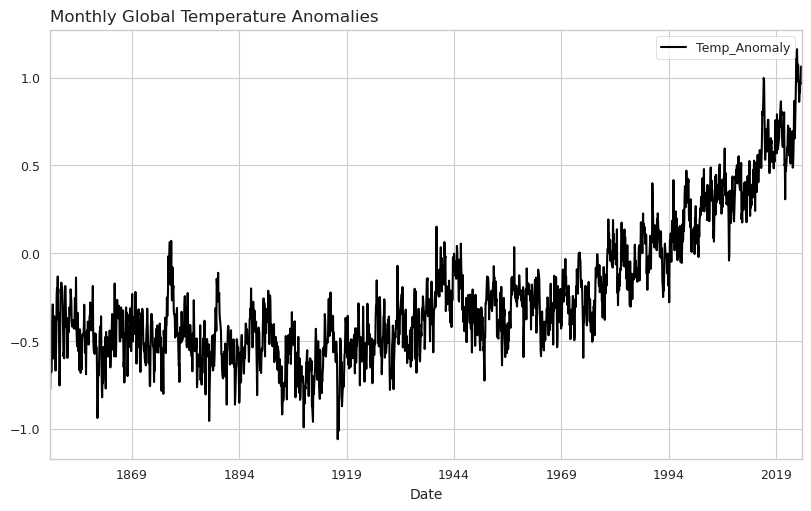

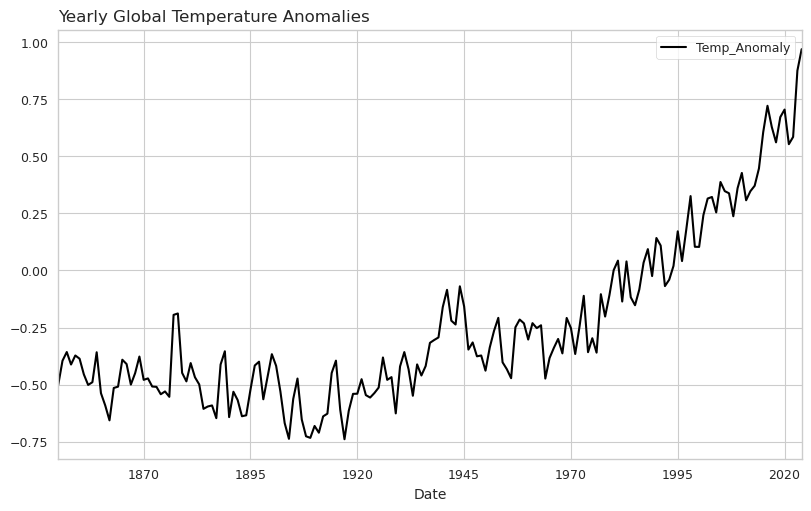

In [58]:
NOAA_global_temp.plot()
plt.title("Monthly Global Temperature Anomalies")
NOAA_global_temp_yearly.plot()
plt.title("Yearly Global Temperature Anomalies")        
plt.show();plt.close()  

Note again in this example how resampling can help reveal the long term trends and patterns in the time series. For example it is well known that the "El niño" phenomenon is associated with a rise in sea surface temperatures. Can you spot this in the yearly time series?

---

::: {.callout-note icon=false}

#### Other Machine Learning Tasks for Time Series

Before ending this session we would like to mention that forecasting is not the only goal in time series analysis. We may be also interested in time series classification. For example, if you have a time series representation of a bird song, can you tell which species it is? There are also clustering problems. Imagine you are a biologist arriving at a new unexplored region and there are several different (but yet unknown to science) species of bats using ultrasounds to move around. Can you use records of their sounds to guess how many species of bats are there?

:::

---

::: {.callout-note  icon=false}

## In the Next Session

First we see how to define so called baseline models for time series forecasting. These are simple models that are easy to implement and that can be used to compare the performance of more complex models. Then we learn about autoregressive and moving average process and we will see that these constitute the foundation of a very important family of forecasting models, the SARIMA models. 

:::

# References